In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

### Load Data:

In [2]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [3]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth for 3 years:

In [6]:
#swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'lat': 'y', 'lon': 'x'})
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)
swe_sca_ds_sierras = swe_sca_ds.rio.clip(sierras.geometry)

In [7]:
swe_sca_ds_sierras = swe_sca_ds_sierras.rename({'y': 'lat', 'x': 'lon'})

In [8]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs_sierras.rename({'y': 'lat', 'x': 'lon'})

In [9]:
swe_sca_ds_allyrs_sierras

<xarray.Dataset> Size: 189GB
Dimensions:      (lat: 1267, lon: 919, time: 13514)
Coordinates:
  * lat          (lat) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * lon          (lon) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>

In [10]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_sierras.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) ))

In [11]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [12]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [13]:
mask

<xarray.DataArray 'SCA_Post' (lat: 1267, lon: 919)> Size: 1MB
dask.array<gt, shape=(1267, 919), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * lon          (lon) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B 0

### Calculate median snow depth for the 3 year period:

In [14]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds_sierras.where(mask)

In [15]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.SD_Post.median(dim=('lat', 'lon'), skipna=True).compute()

### Get timeseries of median/average reanalysis snow depth for all years:

In [16]:
# 4. Apply mask
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_sierras.where(mask)

In [18]:
# 5. Compute spatial median
median_sd_allyrs = swe_sca_ds_allyrs_roi.SD_Post.median(dim=('lat', 'lon'), skipna=True).compute()

In [46]:
# 5. Compute spatial median
median_swe_allyrs = swe_sca_ds_allyrs_roi.SWE_Post.median(dim=('lat', 'lon'), skipna=True).compute()

### Calculating domain-wide fSCA within snowy region for each day of the record

In [104]:
mask

<xarray.DataArray 'SCA_Post' (lat: 1575, lon: 1125)> Size: 2MB
dask.array<gt, shape=(1575, 1125), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0

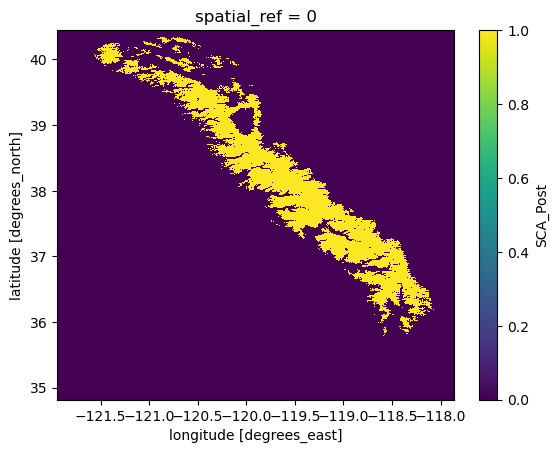

In [34]:
mask.plot()

In [30]:
swe_sca_ds_allyrs_sierras

<xarray.Dataset> Size: 189GB
Dimensions:      (lat: 1267, lon: 919, time: 13514)
Coordinates:
  * lat          (lat) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * lon          (lon) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>

In [28]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs_sierras.rename({'lat': 'y', 'lon': 'x'})
mask = mask.rename({'lat': 'y', 'lon': 'x'})

In [29]:
mask

<xarray.DataArray 'SCA_Post' (y: 1267, x: 919)> Size: 1MB
dask.array<gt, shape=(1267, 919), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B 0

In [30]:
import numpy as np

# Grid spacing in degrees
dx = abs(float(swe_sca_ds_allyrs_sierras.x[1] - swe_sca_ds_allyrs_sierras.x[0]))
dy = abs(float(swe_sca_ds_allyrs_sierras.y[1] - swe_sca_ds_allyrs_sierras.y[0]))

# Calculate cell area accounting for latitude (in m²)
R = 6371000  # Earth radius in meters
lat = swe_sca_ds_allyrs_sierras.y  # latitude values

# Cell area varies with latitude: width shrinks toward poles
# Area = R² * Δlon * (sin(lat + Δlat/2) - sin(lat - Δlat/2))
# Simplified for small cells: Area ≈ R² * cos(lat) * Δlon * Δlat (all in radians)
cell_area = (R ** 2) * np.cos(np.deg2rad(lat)) * np.deg2rad(dx) * np.deg2rad(dy)

# Create mask for pixels that have snow at some point
#ever_snow_mask = (swe_sca_ds_allyrs_sierras.SCA_Post > 0).any(dim='time')

# Calculate fixed total area of the masked region
# cell_area is 1D (varies with y/lat), need to broadcast and sum where mask is True
total_area_fixed = (cell_area * mask).sum().values  # in m²

print(f"Total area of snow-covered region: {total_area_fixed / 1e6:.2f} km²")

# Apply mask to SCA
sca_masked = swe_sca_ds_allyrs_sierras.SCA_Post.where(mask)

Total area of snow-covered region: 21249.05 km²


In [31]:
# Debug: check dimensions
print(f"sca_masked dims: {sca_masked.dims}")
print(f"cell_area dims: {cell_area.dims}")
print(f"(sca_masked * cell_area) dims: {(sca_masked * cell_area).dims}")

sca_masked dims: ('time', 'y', 'x')
cell_area dims: ('y',)
(sca_masked * cell_area) dims: ('time', 'y', 'x')


In [32]:


# Calculate area-weighted mean SCA for each day
# Sum(SCA * cell_area) / total_area
mean_sca_area_weighted = ((sca_masked * cell_area).sum(dim=('y', 'x'), skipna=True) / total_area_fixed).compute()

In [33]:
mean_sca_area_weighted

<xarray.DataArray (time: 13514)> Size: 108kB
array([0.0213501 , 0.15418853, 0.09985778, ..., 0.04285038, 0.02739999,
       0.00016521], shape=(13514,))
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

### Calculate the 7-day running median (match the processing of the ICESAT-2 data)

In [76]:
median_sd_allyrs

<xarray.DataArray 'SD_Post' (time: 13514)> Size: 54kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(13514,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

In [74]:
sd_rolling_7day_median = median_sd_allyrs.rolling(
    time=7, 
    min_periods=1  # Allow calculation even with fewer than 14 days at the start
).median()

sd_rolling_7day_median.name = 'sd_rolling_7day_median'



# Calculate the median date for the rolling windowsd_rolling_7day_median_date = xr.DataArray(sd_rolling_7day_median_date, dims=['time'], coords={'time': median_sd_allyrs['time']})

# Convert time to numeric (nanoseconds), compute rolling median, then convert backsd_rolling_7day_median_date = sd_rolling_7day_median_date.values.astype('datetime64[ns]')

time_numeric = median_sd_allyrs['time'].values.astype('datetime64[ns]').astype(np.int64)
time_da = xr.DataArray(time_numeric, dims=['time'], coords={'time': median_sd_allyrs['time']})
sd_rolling_7day_median_date = time_da.rolling(time=7, min_periods=1).median()
sd_rolling_7day_median_date.name = 'sd_rolling_7day_median_date'


In [75]:
sd_rolling_7day_median_date

<xarray.DataArray 'sd_rolling_7day_median_date' (time: 13514)> Size: 108kB
array([4.6543680e+17, 4.6548000e+17, 4.6552320e+17, ..., 1.6325280e+18,
       1.6326144e+18, 1.6327008e+18], shape=(13514,))
Coordinates:
  * time     (time) datetime64[ns] 108kB 1984-10-01 1984-10-02 ... 2021-09-30

In [35]:
sd_rolling_7day_median

<xarray.DataArray 'sd_rolling_7day_median' (time: 13514)> Size: 54kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(13514,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

### and the rolling 7-day median for SCA:

In [76]:
sca_rolling_7day_median = mean_sca_area_weighted.rolling(
    time=7, 
    min_periods=1  # Allow calculation even with fewer than 14 days at the start
).median()

sca_rolling_7day_median.name = 'sca_rolling_7day_median'

time_numeric_sca = mean_sca_area_weighted['time'].values.astype('datetime64[ns]').astype(np.int64)
time_da_sca = xr.DataArray(time_numeric_sca, dims=['time'], coords={'time': mean_sca_area_weighted['time']})
sca_rolling_7day_median_date = time_da_sca.rolling(time=7, min_periods=1, center=True).median()
sca_rolling_7day_median_date.name = 'sca_rolling_7day_median_date'

# Calculate the median date for the rolling windowsca_rolling_7day_median_date = xr.DataArray(sca_rolling_7day_median_date, dims=['time'], coords={'time': mean_sca_area_weighted['time']})


sca_rolling_7day_median_date = sca_rolling_7day_median_date.values.astype('datetime64[ns]')




### Subsest the ICESat-2 data by snow cover and slope to calculate sample size:

In [20]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [21]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20)]

In [22]:
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Make a timeseries of the ICESat-2 median snow depth:

In [23]:
medians_both = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['n']>100), ['icesat2_3dep_dif', 'reanalysis_sd','acqdate']].dropna().groupby('acqdate').median()

In [24]:
medians_both['date'] = pd.to_datetime(medians_both.index)

In [36]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date
acqdate,,,
2018-10-14,0.075891,0.0,2018-10-14
2018-10-15,-0.108008,0.0,2018-10-15
2018-10-18,0.093040,0.0,2018-10-18
2018-10-19,-0.018844,0.0,2018-10-19
2018-10-23,0.122762,0.0,2018-10-23
...,...,...,...
2021-09-06,-0.059516,0.0,2021-09-06
2021-09-13,-0.000564,0.0,2021-09-13
2021-09-14,-0.055093,0.0,2021-09-14


### Calculate running averages and medians:

In [77]:
# # Calculate 2-week (14-day) running average of icesat2_3dep_dif
# # Using a trailing window that includes the current date
# medians_both['running_average'] = medians_both['icesat2_3dep_dif'].rolling(
#     window=14, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).mean()

# # Calculate 1-week (7-day) running average of icesat2_3dep_dif
# # Using a trailing window that includes the current date
# medians_both['running_average_1week'] = medians_both['icesat2_3dep_dif'].rolling(
#     window=7, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).mean()


# # Calculate 2-week (14-day) running median of icesat2_3dep_dif
# # Using a trailing window that includes the current date
# medians_both['running_median'] = medians_both['icesat2_3dep_dif'].rolling(
#     window=14, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).median()

# Calculate 1-week (7-day) running median of icesat2_3dep_dif
# Using a trailing window that includes the current date
medians_both['running_median_1week'] = medians_both['icesat2_3dep_dif'].rolling(
    window=7, 
    min_periods=1  # Allow calculation even with fewer than 14 days at the start
).median()

# Calculate the median date of the rolling window    

# Convert dates to numeric, compute rolling median, convert back     

medians_both['running_median_1week_date'] = pd.to_datetime(medians_both['date'].astype(np.int64).rolling(window=7,min_periods=1).median())

In [ ]:
# # Calculate 2-week (14-day) running average of reanalysis_sd
# # Using a trailing window that includes the current date
# medians_both['reanalysis_running_average'] = medians_both['reanalysis_sd'].rolling(
#     window=14, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).mean()

# # Calculate 1-week (7-day) running average of reanalysis_sd
# # Using a trailing window that includes the current date
# medians_both['reanalysis_running_average_1week'] = medians_both['reanalysis_sd'].rolling(
#     window=7, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).mean()


# # Calculate 2-week (14-day) running median of reanalysis_sd
# # Using a trailing window that includes the current date
# medians_both['reanalysis_running_median'] = medians_both['reanalysis_sd'].rolling(
#     window=14, 
#     min_periods=1  # Allow calculation even with fewer than 14 days at the start
# ).median()

# Calculate 1-week (7-day) running median of reanalysis_sd
# Using a trailing window that includes the current date
medians_both['reanalysis_running_median_1week'] = medians_both['reanalysis_sd'].rolling(
    window=7, 
    min_periods=1,  # Allow calculation even with fewer than 14 days at the start
    center=True
).median()

# Note: reanalysis uses the same rolling window dates as running_median_1week_date

KeyError: 'running_average'

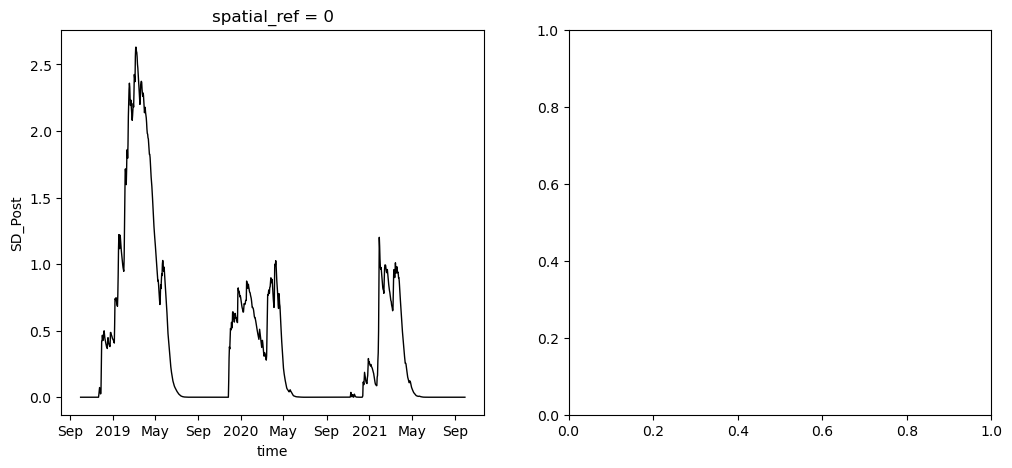

In [27]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd.plot(ax=ax[0], label='Spatial Median', color='k', linewidth=1)
ax[0].scatter(medians_both['date'], medians_both['running_average'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[0].scatter(medians_both['date'], medians_both['reanalysis_running_average'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[0].set_title('14-day Running Mean of ICESat-2 Medians')
ax[0].legend()

median_sd.plot(ax=ax[1], label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
ax[1].scatter(medians_both['date'], medians_both['running_median'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[1].scatter(medians_both['date'], medians_both['reanalysis_running_median'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[1].set_title('14-day Running Median of ICESat-2 Medians')

Text(0.5, 1.0, '7-day Running Median of ICESat-2 Medians')

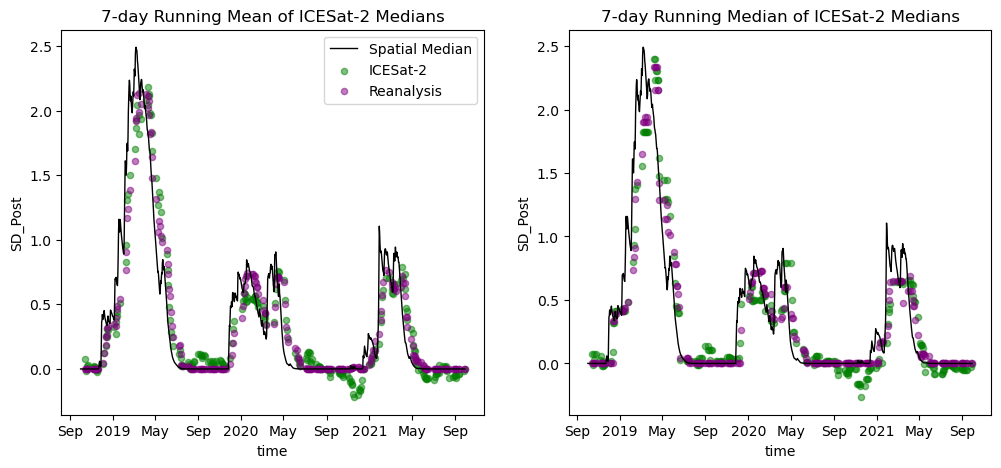

In [64]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd.plot(ax=ax[0], label='Spatial Median', color='k', linewidth=1)
ax[0].scatter(medians_both['date'], medians_both['running_average_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[0].scatter(medians_both['date'], medians_both['reanalysis_running_average_1week'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[0].set_title('7-day Running Mean of ICESat-2 Medians')
ax[0].legend()

median_sd.plot(ax=ax[1], label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
ax[1].scatter(medians_both['date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[1].scatter(medians_both['date'], medians_both['reanalysis_running_median_1week'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[1].set_title('7-day Running Median of ICESat-2 Medians')

In [68]:
median_sd_allyrs_densified = median_sd_allyrs * 0.35
medians_both['icesat2_3dep_dif_densified'] = medians_both['icesat2_3dep_dif'] * 0.35

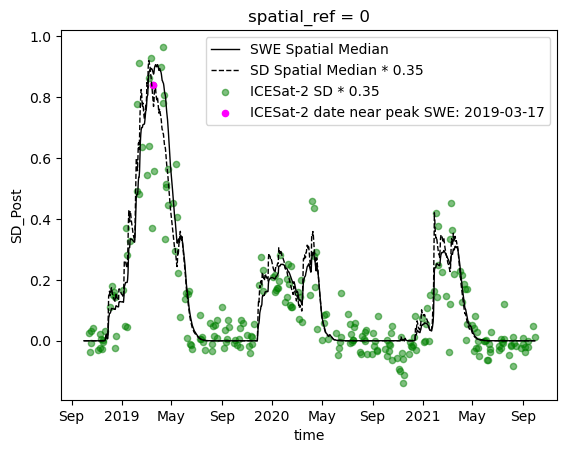

In [103]:
fig, ax = plt.subplots()

median_swe_allyrs.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='SWE Spatial Median', color='k', linewidth=1)
median_sd_allyrs_densified.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='SD Spatial Median * 0.35', color='k', linewidth=1, linestyle='--')
ax.scatter(medians_both['date'], medians_both['icesat2_3dep_dif_densified'], s=20, alpha=0.5, c='green', label='ICESat-2 SD * 0.35')
ax.scatter(medians_both.loc[(medians_both['date']=='2019-03-17'),'date'], medians_both.loc[(medians_both['date']=='2019-03-17'),'icesat2_3dep_dif_densified'], s=20, c='magenta', label='ICESat-2 date near peak SWE: 2019-03-17')
ax.legend()

Text(0.5, 1.0, 'ICESat-2 Snow Depth on 2019-03-17')

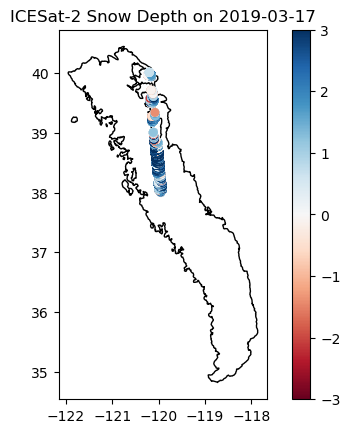

In [99]:
fig, ax = plt.subplots()
sierras.plot(ax=ax, facecolor='none', edgecolor='k')
atl06sr_gdf_snowy.loc[atl06sr_gdf_snowy['acqdate_dt']=='2019-03-17'].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3)

plt.title('ICESat-2 Snow Depth on 2019-03-17')

In [86]:
medians_both['date'].head(40)

0    2018-10-14
1    2018-10-15
2    2018-10-18
3    2018-10-19
4    2018-10-23
5    2018-11-04
6    2018-11-08
7    2018-11-09
8    2018-11-12
9    2018-11-13
10   2018-11-16
11   2018-11-17
12   2018-11-20
13   2018-12-03
14   2018-12-07
15   2018-12-11
16   2018-12-12
17   2018-12-15
18   2018-12-16
19   2018-12-19
20   2019-01-05
21   2019-01-09
22   2019-01-10
23   2019-01-13
24   2019-01-14
25   2019-01-22
26   2019-02-07
27   2019-02-08
28   2019-02-11
29   2019-02-12
30   2019-02-19
31   2019-03-04
32   2019-03-08
33   2019-03-09
34   2019-03-12
35   2019-03-16
36   2019-03-17
37   2019-03-21
38   2019-04-06
39   2019-04-10
Name: date, dtype: datetime64[ns]

In [ ]:
swe_rolling_7day_median = median_swe_allyrs.rolling(
    time=7, 
    min_periods=1,  # Allow calculation even with fewer than 14 days at the start
    center=True
).median()

swe_rolling_7day_median.name = 'swe_rolling_7day_median'

time_numeric_swe = median_swe_allyrs['time'].values.astype('datetime64[ns]').astype(np.int64)
time_da_swe = xr.DataArray(time_numeric_swe, dims=['time'], coords={'time': median_swe_allyrs['time']})


# Calculate the median date for the rolling windowswe_rolling_7day_median_date = xr.DataArray(swe_rolling_7day_median_date, dims=['time'], coords={'time': median_swe_allyrs['time']})

swe_rolling_7day_median_date = time_da_swe.rolling(time=7, min_periods=1, center=True).median()
swe_rolling_7day_median_date.name = 'swe_rolling_7day_median_date'
swe_rolling_7day_median_date = swe_rolling_7day_median_date.values.astype('datetime64[ns]')

In [80]:
sd_rolling_7day_median_densified = sd_rolling_7day_median * 0.35
medians_both['running_median_1week'] = medians_both['running_median_1week'] * 0.35

In [81]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,mean_sca_area_weighted,water_year,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season,icesat2_3dep_dif_densified,running_median_1week_date
0,0.075891,0.0,2018-10-14,0.026562,0.0,0.021475,2019,False,NaN,NaN,NaN,NaN,NaN,0.026562,2018-10-14 00:00:00
1,-0.108008,0.0,2018-10-15,-0.005620,0.0,0.020042,2019,False,NaN,NaN,NaN,NaN,NaN,-0.037803,2018-10-14 12:00:00
2,0.093040,0.0,2018-10-18,0.026562,0.0,0.013644,2019,False,NaN,NaN,NaN,NaN,NaN,0.032564,2018-10-15 00:00:00
3,-0.018844,0.0,2018-10-19,0.009983,0.0,0.012853,2019,False,NaN,NaN,NaN,NaN,NaN,-0.006596,2018-10-16 12:00:00
4,0.122762,0.0,2018-10-23,0.026562,0.0,0.015295,2019,False,NaN,NaN,NaN,NaN,NaN,0.042967,2018-10-18 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.018412,0.0,0.000055,2021,False,NaN,NaN,NaN,NaN,NaN,-0.020830,2021-09-01 00:00:00
256,-0.000564,0.0,2021-09-13,-0.018412,0.0,0.000049,2021,False,NaN,NaN,NaN,NaN,NaN,-0.000197,2021-09-02 00:00:00
257,-0.055093,0.0,2021-09-14,-0.019282,0.0,0.000048,2021,False,NaN,NaN,NaN,NaN,NaN,-0.019282,2021-09-05 00:00:00
258,0.138069,0.0,2021-09-26,-0.010876,0.0,0.000047,2021,False,NaN,NaN,NaN,NaN,NaN,0.048324,2021-09-06 00:00:00


Text(0.5, 1.0, '7-day Running Median using the Median of the Dates')

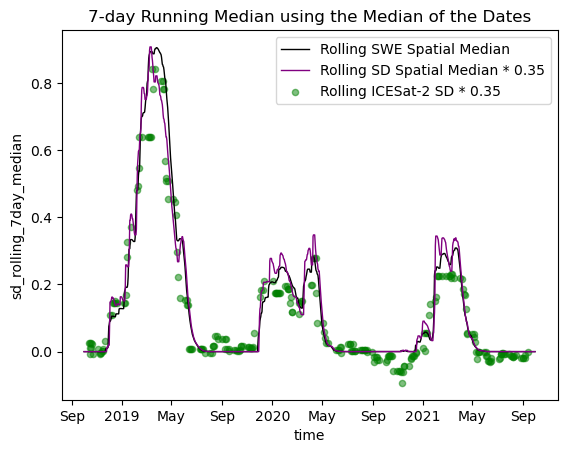

In [83]:
fig, ax = plt.subplots()

swe_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='Rolling SWE Spatial Median', color='k', linewidth=1)
sd_rolling_7day_median_densified.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='Rolling SD Spatial Median * 0.35', color='purple', linewidth=1)
ax.scatter(medians_both['running_median_1week_date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='Rolling ICESat-2 SD * 0.35')
ax.legend()
ax.set_title('7-day Running Median using the Median of the Dates')

### Compare the 7 day rolling medians from the reanalysis and icesat2 data:

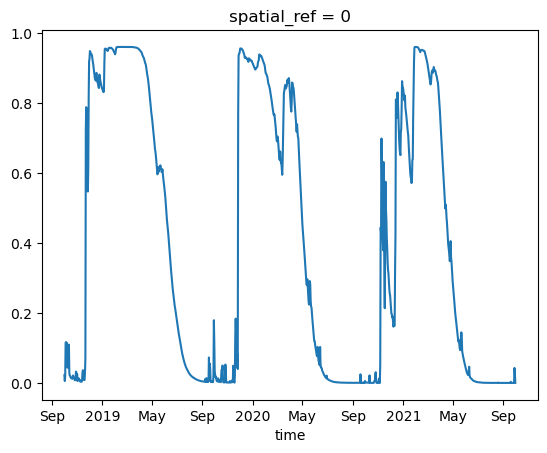

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the SCA time series
sca_subset = mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30'))
sca_subset.plot(ax=ax)

# Find and shade periods where SCA == 0
times = pd.to_datetime(sca_subset.time.values)
sca_values = sca_subset.values

# Find transitions to/from zero
is_zero = sca_values == 0
in_zero_period = False
start_idx = None

for i, (t, zero) in enumerate(zip(times, is_zero)):
    if zero and not in_zero_period:
        # Start of zero period
        start_idx = i
        in_zero_period = True
    elif not zero and in_zero_period:
        # End of zero period
        ax.axvspan(times[start_idx], times[i-1], alpha=0.3, color='red', zorder=0, label='SCA = 0' if start_idx == 0 or 'SCA = 0' not in [t.get_text() for t in ax.get_legend_handles_labels()[1]] else '')
        in_zero_period = False

# Handle case where series ends in zero period
if in_zero_period:
    ax.axvspan(times[start_idx], times[-1], alpha=0.3, color='red', zorder=0)

ax.set_title('Area-Weighted Mean SCA (WY 2019-2021)', fontsize=14)
ax.set_ylabel('SCA')
ax.legend(['SCA', 'SCA = 0'])
plt.tight_layout()
plt.show()

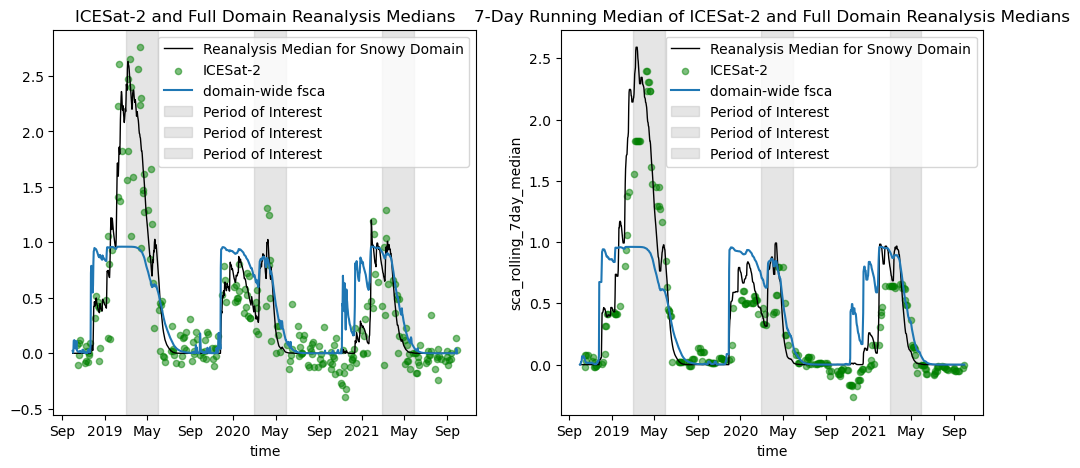

In [37]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd_allyrs.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[0].scatter(medians_both['date'], medians_both['icesat2_3dep_dif'], s=20, alpha=0.5, c='green', label='ICESat-2')
mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], label='domain-wide fsca')
ax[0].set_title('ICESat-2 and Full Domain Reanalysis Medians')


sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[1].scatter(medians_both['date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
sca_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], label='domain-wide fsca')
ax[1].set_title('7-Day Running Median of ICESat-2 and Full Domain Reanalysis Medians')

# Add shaded regions for March 1 - May 31 of each year to both subplots
for year in [2019, 2020, 2021]:
    for a in ax:
        a.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0, label='Period of Interest')
        
ax[0].legend()
ax[1].legend()

In [73]:
mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30')).where(mean_sca_area_weighted==0)

<xarray.DataArray (time: 1096)> Size: 9kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(1096,))
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0

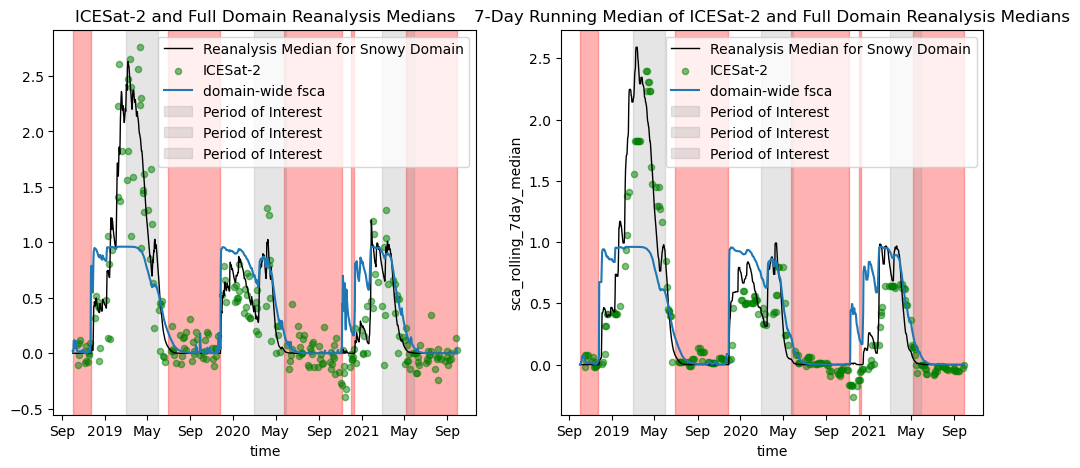

In [37]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd_allyrs.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[0].scatter(medians_both['date'], medians_both['icesat2_3dep_dif'], s=20, alpha=0.5, c='green', label='ICESat-2')
mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], label='domain-wide fsca')
ax[0].set_title('ICESat-2 and Full Domain Reanalysis Medians')


sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[1].scatter(medians_both['date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
sca_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], label='domain-wide fsca')
ax[1].set_title('7-Day Running Median of ICESat-2 and Full Domain Reanalysis Medians')

# Shade periods where mean_sca_area_weighted == 0
sca_subset = mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30'))
times = pd.to_datetime(sca_subset.time.values)
sca_values = sca_subset.values
is_zero = sca_values < 0.2
in_zero_period = False
start_idx = None

for i, (t, zero) in enumerate(zip(times, is_zero)):
    if zero and not in_zero_period:
        start_idx = i
        in_zero_period = True
    elif not zero and in_zero_period:
        for a in ax:
            a.axvspan(times[start_idx], times[i-1], alpha=0.3, color='red', zorder=0)
        in_zero_period = False

if in_zero_period:
    for a in ax:
        a.axvspan(times[start_idx], times[-1], alpha=0.3, color='red', zorder=0)

# Add shaded regions for March 1 - May 31 of each year to both subplots
for year in [2019, 2020, 2021]:
    for a in ax:
        a.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0, label='Period of Interest')
        
ax[0].legend()
ax[1].legend()

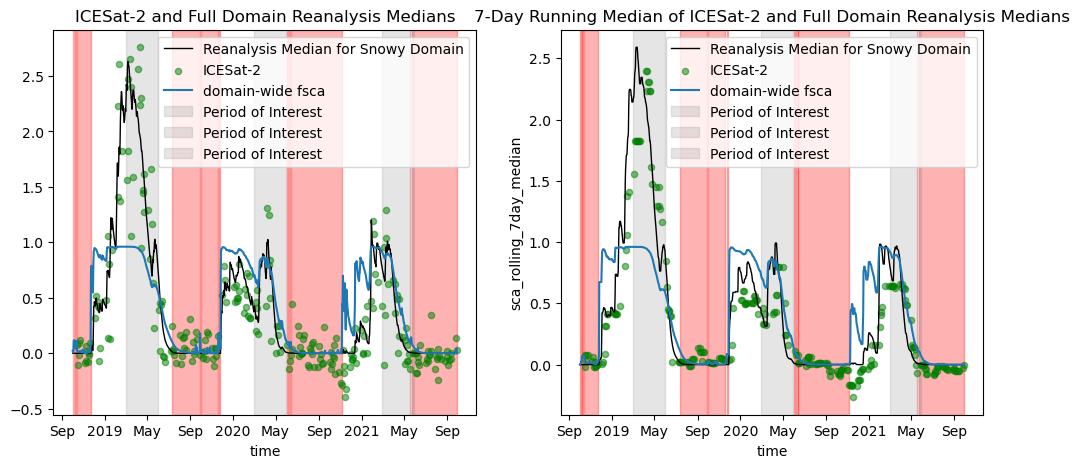

In [77]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd_allyrs.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[0].scatter(medians_both['date'], medians_both['icesat2_3dep_dif'], s=20, alpha=0.5, c='green', label='ICESat-2')
mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[0], label='domain-wide fsca')
ax[0].set_title('ICESat-2 and Full Domain Reanalysis Medians')


sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[1].scatter(medians_both['date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
sca_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], label='domain-wide fsca')
ax[1].set_title('7-Day Running Median of ICESat-2 and Full Domain Reanalysis Medians')

# Shade periods where mean_sca_area_weighted == 0
sca_subset = mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30'))
times = pd.to_datetime(sca_subset.time.values)
sca_values = sca_subset.values
is_zero = sca_values < 0.1
in_zero_period = False
start_idx = None

for i, (t, zero) in enumerate(zip(times, is_zero)):
    if zero and not in_zero_period:
        start_idx = i
        in_zero_period = True
    elif not zero and in_zero_period:
        for a in ax:
            a.axvspan(times[start_idx], times[i-1], alpha=0.3, color='red', zorder=0)
        in_zero_period = False

if in_zero_period:
    for a in ax:
        a.axvspan(times[start_idx], times[-1], alpha=0.3, color='red', zorder=0)

# Add shaded regions for March 1 - May 31 of each year to both subplots
for year in [2019, 2020, 2021]:
    for a in ax:
        a.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0, label='Period of Interest')
        
ax[0].legend()
ax[1].legend()

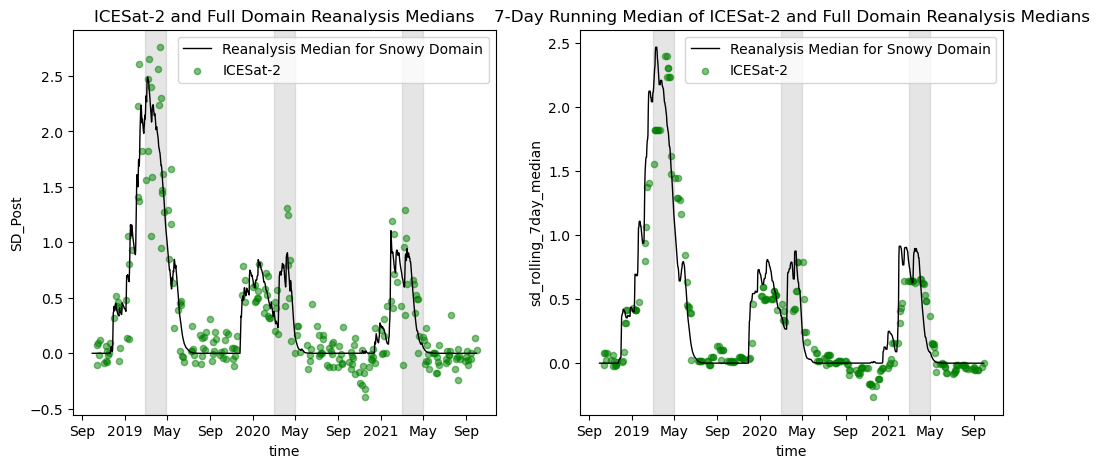

In [88]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd.plot(ax=ax[0], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[0].scatter(medians_both['date'], medians_both['icesat2_3dep_dif'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[0].set_title('ICESat-2 and Full Domain Reanalysis Medians')
ax[0].legend()

sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax[1], color='k', linewidth=1, label='Reanalysis Median for Snowy Domain')
ax[1].scatter(medians_both['date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[1].set_title('7-Day Running Median of ICESat-2 and Full Domain Reanalysis Medians')
ax[1].legend()

# Add shaded regions for March 1 - May 31 of each year to both subplots
for year in [2019, 2020, 2021]:
    for a in ax:
        a.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-04-30'), 
                   alpha=0.2, color='gray', zorder=0)

plot reanalysis swe (apply constant density) to identify impacts of depth vs swe (fluffy vs compacted). Identify the major forces of noise and disagreement. when is is2 giving us goo dinformation and when does it have issues.  
plot the date offset equally for both.
plot reanalysis depth and constant scaled swe (0.35 or 0.4) with smoothed icesat2 for 2019 (not a weird year). don't want to do anything within 3 days of snowfall, this will look weird in snow depth and fsca. ASO does this strategically too (doesn't fly right after snowfall). do icesat2 have a nice spatial progression in time?  
start with 2019, plot the temporal icesat2 over the sierra for the snow season to see if it's a progression in space. (jessica says swe (did she mean snow depth) didn't change too much between february and april)  
we could look at precip data to see when there was snow (could even just use a snotel)
overall we're trying to filter so we're not too close to new snow and not too far into the melt either.
does it help to do an average acrosss fsca dates, like are those all really well correlated? jessica's looking at the week in 2019 with consistently high fsca

### Calculate the cumulative increases and decreases of the ICESat-2 snow depth for each water year:

In [38]:
# Sort by date to ensure proper ordering
#medians_both = medians_both.sort_values('date').reset_index(drop=True)

# Assign water year (WY starts Oct 1 of previous year, ends Sep 30 of current year)
# e.g., Oct 1 2019 - Sep 30 2020 = WY 2020
medians_both['water_year'] = medians_both['date'].apply(
    lambda x: x.year + 1 if x.month >= 10 else x.year
)

# Calculate daily changes in icesat2_3dep_dif
medians_both['daily_change_median_1week'] = medians_both.groupby('water_year')['running_median_1week'].diff()

# Separate increases (positive changes) and decreases (negative changes)
medians_both['increase_median_1week'] = medians_both['daily_change_median_1week'].clip(lower=0)  # Keep only positive values
medians_both['decrease_median_1week'] = medians_both['daily_change_median_1week'].clip(upper=0)  # Keep only negative values

# Calculate cumulative sums within each water year
medians_both['cumulative_increase_median_1week'] = medians_both.groupby('water_year')['increase_median_1week'].cumsum()
medians_both['cumulative_decrease_median_1week'] = medians_both.groupby('water_year')['decrease_median_1week'].cumsum()

# Fill NaN values (first day of each water year) with 0
medians_both['cumulative_increase_median_1week'] = medians_both['cumulative_increase_median_1week'].fillna(0)
medians_both['cumulative_decrease_median_1week'] = medians_both['cumulative_decrease_median_1week'].fillna(0)

# Optional: drop intermediate columns if not needed
# medians_both = medians_both.drop(columns=['daily_change', 'increase', 'decrease'])


In [43]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_average,running_average_1week,running_median,running_median_1week,reanalysis_running_average,reanalysis_running_average_1week,reanalysis_running_median,reanalysis_running_median_1week
acqdate,,,,,,,,,,,
2018-10-14,0.075891,0.0,2018-10-14,0.075891,0.075891,0.075891,0.075891,0.0,0.0,0.0,0.0
2018-10-15,-0.108008,0.0,2018-10-15,-0.016058,-0.016058,-0.016058,-0.016058,0.0,0.0,0.0,0.0
2018-10-18,0.093040,0.0,2018-10-18,0.020308,0.020308,0.075891,0.075891,0.0,0.0,0.0,0.0
2018-10-19,-0.018844,0.0,2018-10-19,0.010520,0.010520,0.028523,0.028523,0.0,0.0,0.0,0.0
2018-10-23,0.122762,0.0,2018-10-23,0.032968,0.032968,0.075891,0.075891,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2021-09-06,-0.059516,0.0,2021-09-06,-0.026410,-0.044901,-0.041699,-0.052606,0.0,0.0,0.0,0.0
2021-09-13,-0.000564,0.0,2021-09-13,-0.027615,-0.041879,-0.041699,-0.052606,0.0,0.0,0.0,0.0
2021-09-14,-0.055093,0.0,2021-09-14,-0.056387,-0.042234,-0.049727,-0.055093,0.0,0.0,0.0,0.0


### Calculate the cumulative increases and decreases of the ICESat-2 snow depth for each water year applying fSCA thresholding:

In [39]:
# Look up SCA values for each ICESat-2 date from the daily SCA time series
# Use .sel with method='nearest' to handle any slight date mismatches
medians_both['sca_rolling_7day_median'] = medians_both['date'].apply(
    lambda d: float(sca_rolling_7day_median.sel(time=d, method='nearest').values)
)

# Assign water year if not already done
if 'water_year' not in medians_both.columns:
    medians_both['water_year'] = medians_both['date'].apply(
        lambda x: x.year + 1 if x.month >= 10 else x.year
    )

# Thresholds
SCA_THRESHOLD = 0.5  # SCA must be > 0.05 to be considered "in snow season"
SUSTAINED_DAYS = 14  # Must stay above threshold for 2 weeks before counting

# Drop any existing snow season columns to avoid _x/_y suffixes on re-run
cols_to_drop = [col for col in medians_both.columns if 'snow_season' in col]
if cols_to_drop:
    medians_both = medians_both.drop(columns=cols_to_drop)

# Create a mask for valid snow season dates using the daily SCA data
def get_snow_season_mask(group):
    """
    For each water year:
    - Start when SCA stays > threshold for more than 2 weeks
    - End when SCA < threshold after April 1
    """
    group = group.sort_values('date').copy()
    wy = group['water_year'].iloc[0]
    april_1 = pd.Timestamp(year=wy, month=4, day=1)
    
    # Get the daily SCA data for this water year to check sustained periods
    wy_start = pd.Timestamp(year=wy-1, month=10, day=1)
    wy_end = pd.Timestamp(year=wy, month=9, day=30)
    
    sca_wy = sca_rolling_7day_median.sel(time=slice(wy_start, wy_end))
    sca_times = pd.to_datetime(sca_wy.time.values)
    sca_values = sca_wy.values
    
    # Find the first date where SCA stays above threshold for SUSTAINED_DAYS
    above_threshold = sca_values > SCA_THRESHOLD
    first_sustained_date = None
    
    for i in range(len(above_threshold)):
        if above_threshold[i]:
            # Check if it stays above threshold for SUSTAINED_DAYS
            end_check = min(i + SUSTAINED_DAYS, len(above_threshold))
            if all(above_threshold[i:end_check]) and (end_check - i) >= SUSTAINED_DAYS:
                first_sustained_date = sca_times[i]  # Start at beginning of sustained period
                break
    
    if first_sustained_date is None:
        group['in_snow_season'] = False
        return group
    
    # Find first date after April 1 with SCA < threshold (snow off)
    after_april1_mask = sca_times >= april_1
    below_threshold_after_april = after_april1_mask & (sca_values < SCA_THRESHOLD)
    
    if below_threshold_after_april.any():
        first_snow_off_date = sca_times[np.argmax(below_threshold_after_april)]
    else:
        first_snow_off_date = None
    
    # Apply mask to ICESat-2 dates
    if first_snow_off_date is not None:
        group['in_snow_season'] = (group['date'] >= first_sustained_date) & (group['date'] < first_snow_off_date)
    else:
        group['in_snow_season'] = (group['date'] >= first_sustained_date)
    
    return group

# Apply the snow season mask by water year
medians_both = medians_both.groupby('water_year', group_keys=False).apply(get_snow_season_mask)

# Now calculate cumulative changes only for dates in snow season
medians_snow_season = medians_both[medians_both['in_snow_season']].copy()

# Calculate daily changes within snow season
medians_snow_season['daily_change_snow_season'] = medians_snow_season.groupby('water_year')['running_median_1week'].diff()

# Separate increases and decreases
medians_snow_season['increase_snow_season'] = medians_snow_season['daily_change_snow_season'].clip(lower=0)
medians_snow_season['decrease_snow_season'] = medians_snow_season['daily_change_snow_season'].clip(upper=0)

# Calculate cumulative sums within each water year
medians_snow_season['cumulative_increase_snow_season'] = medians_snow_season.groupby('water_year')['increase_snow_season'].cumsum()
medians_snow_season['cumulative_decrease_snow_season'] = medians_snow_season.groupby('water_year')['decrease_snow_season'].cumsum()

# Fill NaN values with 0
medians_snow_season['cumulative_increase_snow_season'] = medians_snow_season['cumulative_increase_snow_season'].fillna(0)
medians_snow_season['cumulative_decrease_snow_season'] = medians_snow_season['cumulative_decrease_snow_season'].fillna(0)

# Merge the new snow season columns back to medians_both
new_cols = ['daily_change_snow_season', 'increase_snow_season', 'decrease_snow_season', 
            'cumulative_increase_snow_season', 'cumulative_decrease_snow_season']

medians_both = medians_both.merge(
    medians_snow_season[['date'] + new_cols],
    on='date',
    how='left'
)

print(f"Snow season dates per water year (SCA > {SCA_THRESHOLD} sustained for {SUSTAINED_DAYS} days):")
for wy in sorted(medians_both['water_year'].unique()):
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        print(f"  WY {wy}: {wy_data['date'].min().strftime('%Y-%m-%d')} to {wy_data['date'].max().strftime('%Y-%m-%d')} ({len(wy_data)} dates)")

Snow season dates per water year (SCA > 0.5 sustained for 14 days):
  WY 2019: 2018-12-03 to 2019-06-07 (42 dates)
  WY 2020: 2019-12-01 to 2020-04-19 (33 dates)
  WY 2021: 2020-12-31 to 2021-04-15 (26 dates)


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_45381/648355657.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  medians_both = medians_both.groupby('water_year', group_keys=False).apply(get_snow_season_mask)


In [90]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,water_year,daily_change_median_1week,increase_median_1week,decrease_median_1week,cumulative_increase_median_1week,cumulative_decrease_median_1week,sca_rolling_7day_median,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season
0,0.075891,0.0,2018-10-14,0.075891,0.0,2019,NaN,NaN,NaN,0.000000,0.000000,0.052785,False,NaN,NaN,NaN,NaN,NaN
1,-0.108008,0.0,2018-10-15,-0.016058,0.0,2019,-0.091949,0.000000,-0.091949,0.000000,-0.091949,0.043546,False,NaN,NaN,NaN,NaN,NaN
2,0.093040,0.0,2018-10-18,0.075891,0.0,2019,0.091949,0.091949,0.000000,0.091949,-0.091949,0.020042,False,NaN,NaN,NaN,NaN,NaN
3,-0.018844,0.0,2018-10-19,0.028523,0.0,2019,-0.047368,0.000000,-0.047368,0.091949,-0.139317,0.016110,False,NaN,NaN,NaN,NaN,NaN
4,0.122762,0.0,2018-10-23,0.075891,0.0,2019,0.047368,0.047368,0.000000,0.139317,-0.139317,0.014465,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000060,False,NaN,NaN,NaN,NaN,NaN
256,-0.000564,0.0,2021-09-13,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000054,False,NaN,NaN,NaN,NaN,NaN
257,-0.055093,0.0,2021-09-14,-0.055093,0.0,2021,-0.002486,0.000000,-0.002486,1.332635,-1.337789,0.000053,False,NaN,NaN,NaN,NaN,NaN
258,0.138069,0.0,2021-09-26,-0.031074,0.0,2021,0.024019,0.024019,0.000000,1.356654,-1.337789,0.000047,False,NaN,NaN,NaN,NaN,NaN


### Calculate the cumulative increases and decreases of the Reanalysis snow depth for each water year:

In [40]:
# Convert DataArray to DataFrame for easier manipulation
sd_rolling_df = sd_rolling_7day_median.to_dataframe(name='sd_rolling_7day_median').reset_index()

# Assign water year (WY starts Oct 1 of previous year, ends Sep 30 of current year)
sd_rolling_df['water_year'] = sd_rolling_df['time'].apply(
    lambda x: x.year + 1 if x.month >= 10 else x.year
)

# Sort by time to ensure proper ordering
sd_rolling_df = sd_rolling_df.sort_values('time').reset_index(drop=True)

# Calculate daily changes in sd_rolling_7day_median
sd_rolling_df['daily_change'] = sd_rolling_df.groupby('water_year')['sd_rolling_7day_median'].diff()

# Separate increases (positive changes) and decreases (negative changes)
sd_rolling_df['increase'] = sd_rolling_df['daily_change'].clip(lower=0)
sd_rolling_df['decrease'] = sd_rolling_df['daily_change'].clip(upper=0)

# Calculate cumulative sums within each water year
sd_rolling_df['cumulative_increase'] = sd_rolling_df.groupby('water_year')['increase'].cumsum()
sd_rolling_df['cumulative_decrease'] = sd_rolling_df.groupby('water_year')['decrease'].cumsum()

# Fill NaN values (first day of each water year) with 0
sd_rolling_df['cumulative_increase'] = sd_rolling_df['cumulative_increase'].fillna(0)
sd_rolling_df['cumulative_decrease'] = sd_rolling_df['cumulative_decrease'].fillna(0)

# Optional: convert back to xarray Dataset if needed
#sd_rolling_ds = sd_rolling_df.set_index('time').to_xarray()

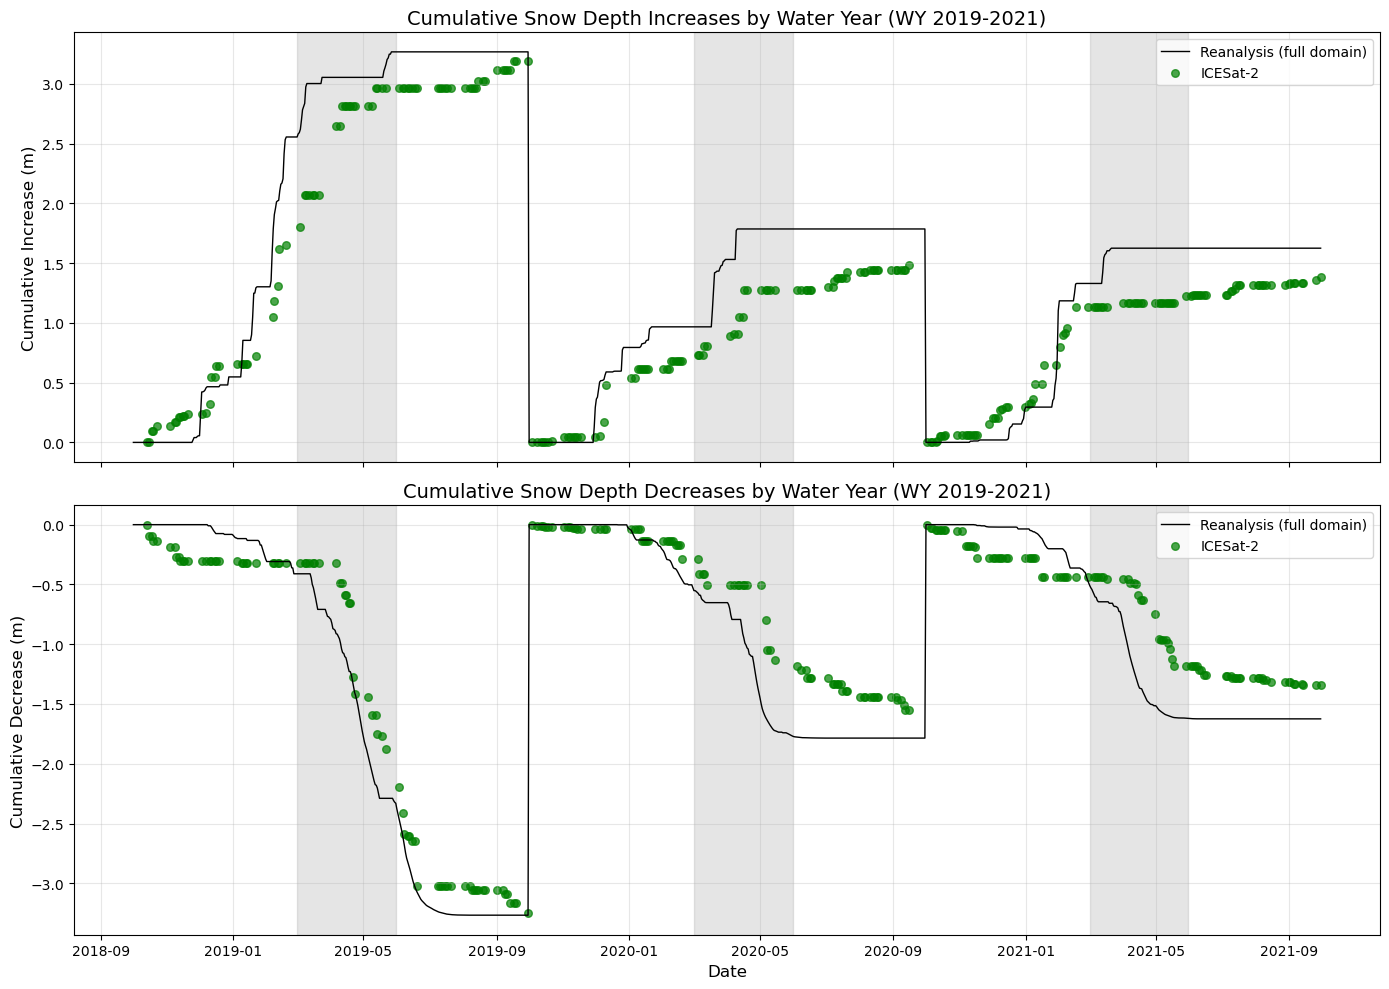

In [41]:
# Filter reanalysis data to ICESat-2 period
sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot cumulative increase
axes[0].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[0].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[0].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[0].set_title('Cumulative Snow Depth Increases by Water Year (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot cumulative decrease
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Decreases by Water Year (WY 2019-2021)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

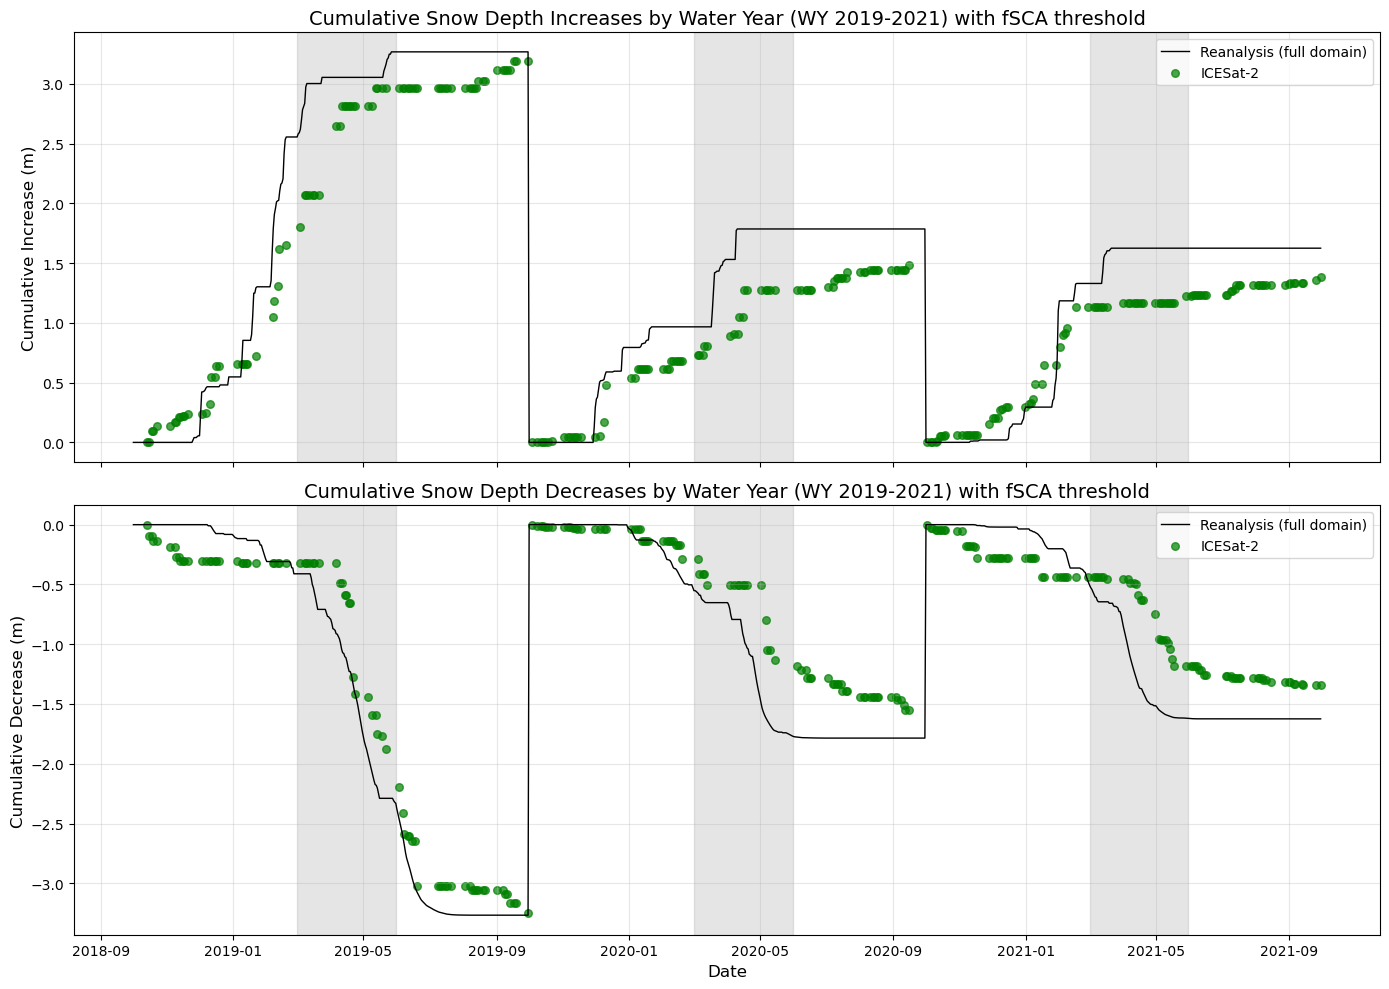

In [57]:
# Filter reanalysis data to ICESat-2 period
sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot cumulative increase
axes[0].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[0].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season_y'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[0].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[0].set_title('Cumulative Snow Depth Increases by Water Year (WY 2019-2021) with fSCA threshold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot cumulative decrease
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season_y'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Decreases by Water Year (WY 2019-2021) with fSCA threshold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

In [83]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,water_year,daily_change_median_1week,increase_median_1week,decrease_median_1week,cumulative_increase_median_1week,...,daily_change_snow_season_x,increase_snow_season_x,decrease_snow_season_x,cumulative_increase_snow_season_x,cumulative_decrease_snow_season_x,daily_change_snow_season_y,increase_snow_season_y,decrease_snow_season_y,cumulative_increase_snow_season_y,cumulative_decrease_snow_season_y
0,0.075891,0.0,2018-10-14,0.075891,0.0,2019,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,-0.108008,0.0,2018-10-15,-0.016058,0.0,2019,-0.091949,0.000000,-0.091949,0.000000,...,-0.091949,0.000000,-0.091949,0.000000,-0.091949,NaN,NaN,NaN,NaN,NaN
2,0.093040,0.0,2018-10-18,0.075891,0.0,2019,0.091949,0.091949,0.000000,0.091949,...,0.091949,0.091949,0.000000,0.091949,-0.091949,NaN,NaN,NaN,NaN,NaN
3,-0.018844,0.0,2018-10-19,0.028523,0.0,2019,-0.047368,0.000000,-0.047368,0.091949,...,-0.047368,0.000000,-0.047368,0.091949,-0.139317,NaN,NaN,NaN,NaN,NaN
4,0.122762,0.0,2018-10-23,0.075891,0.0,2019,0.047368,0.047368,0.000000,0.139317,...,0.047368,0.047368,0.000000,0.139317,-0.139317,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,...,0.000000,0.000000,0.000000,1.332635,-1.335303,NaN,NaN,NaN,NaN,NaN
256,-0.000564,0.0,2021-09-13,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,...,0.000000,0.000000,0.000000,1.332635,-1.335303,NaN,NaN,NaN,NaN,NaN
257,-0.055093,0.0,2021-09-14,-0.055093,0.0,2021,-0.002486,0.000000,-0.002486,1.332635,...,-0.002486,0.000000,-0.002486,1.332635,-1.337789,NaN,NaN,NaN,NaN,NaN
258,0.138069,0.0,2021-09-26,-0.031074,0.0,2021,0.024019,0.024019,0.000000,1.356654,...,0.024019,0.024019,0.000000,1.356654,-1.337789,NaN,NaN,NaN,NaN,NaN


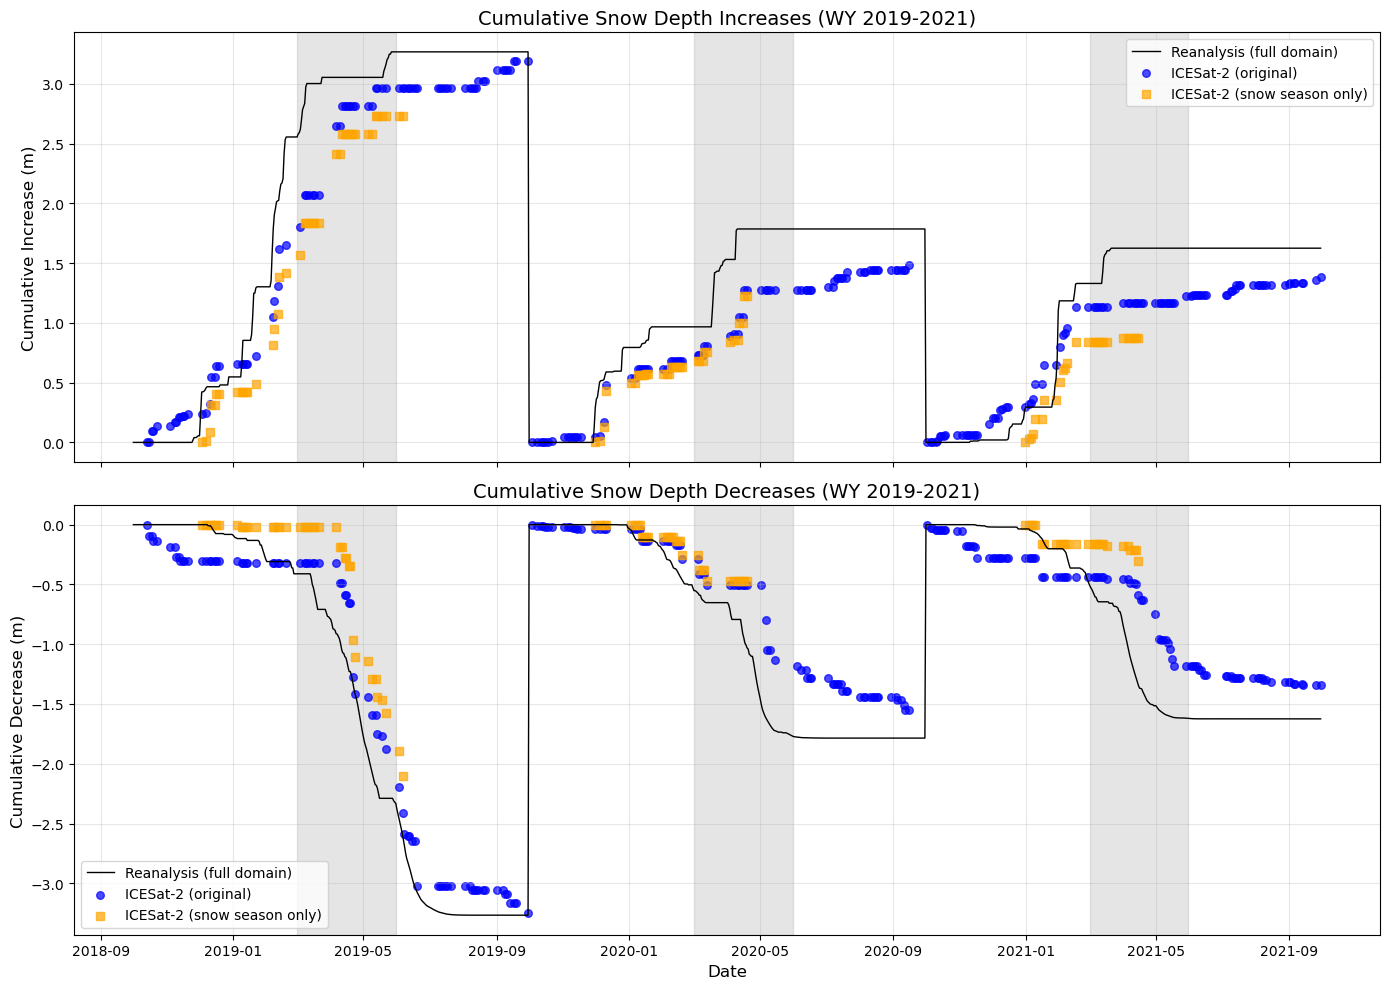

In [42]:
# Filter reanalysis data to ICESat-2 period
sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

# Filter to only snow season dates for the thresholded values
medians_snow_season_only = medians_both[medians_both['in_snow_season'] == True].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top subplot: Cumulative Increases - both methods
axes[0].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
              color='k', linewidth=1, label='Reanalysis (full domain)')
axes[0].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                 s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
# Use the column without _y suffix, and filter to snow season only
axes[0].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                 s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[0].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[0].set_title('Cumulative Snow Depth Increases (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
              color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                 s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                 s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Decreases (WY 2019-2021)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

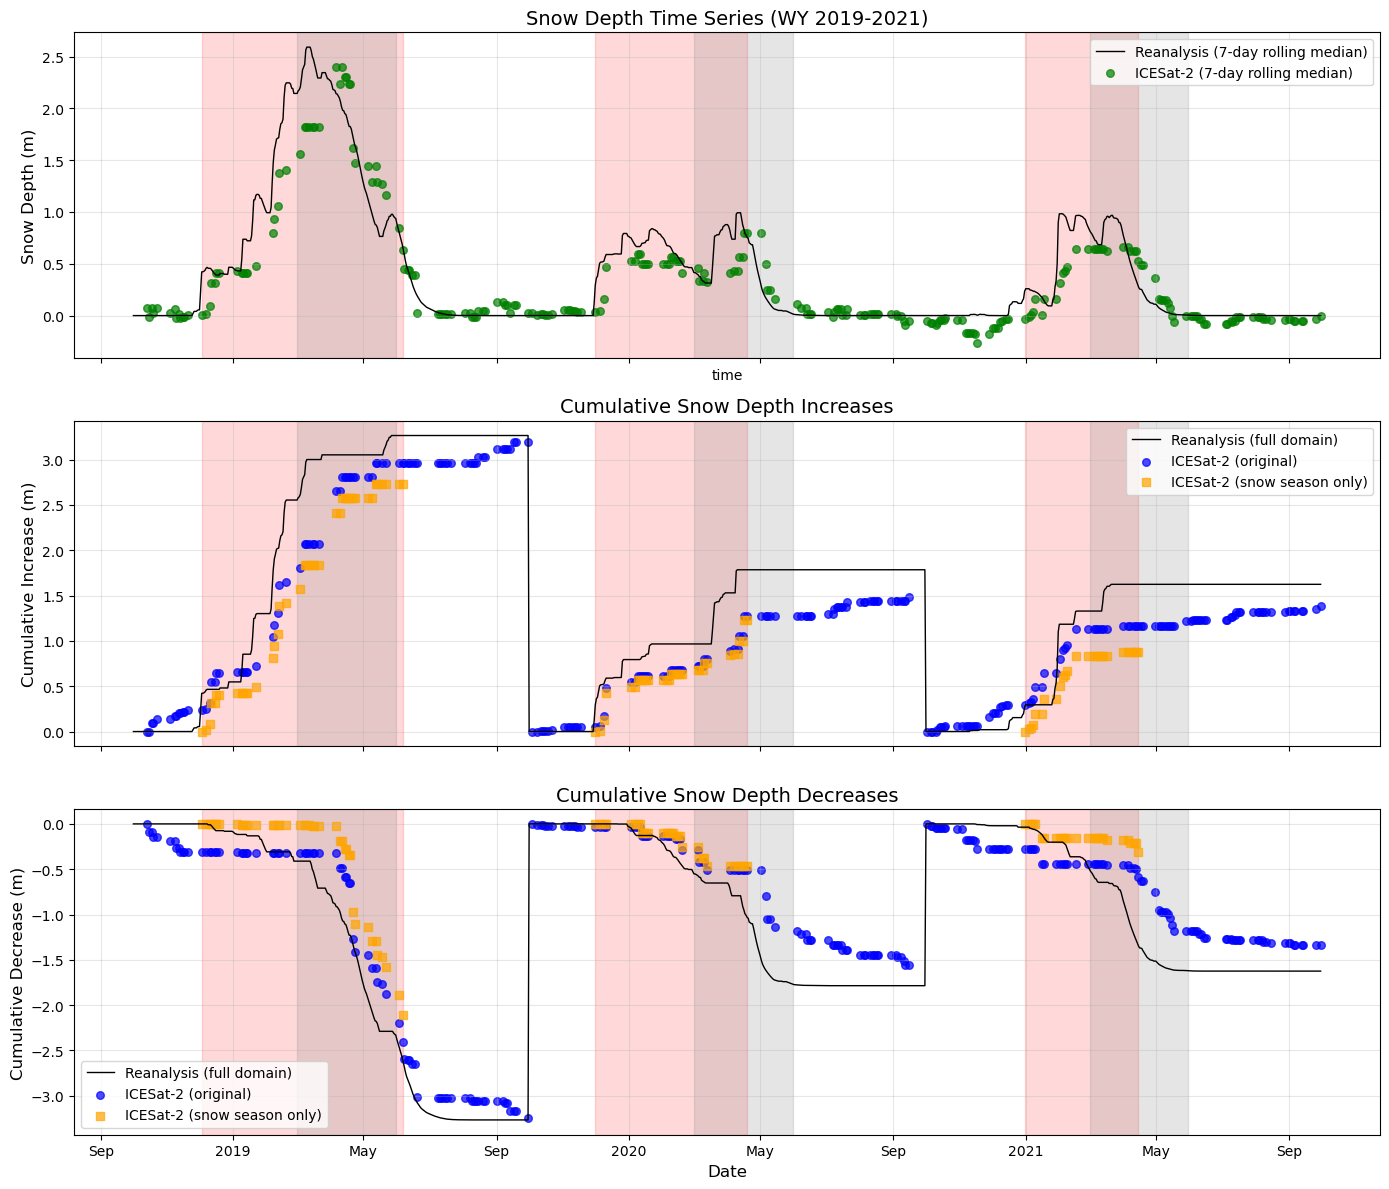

In [43]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

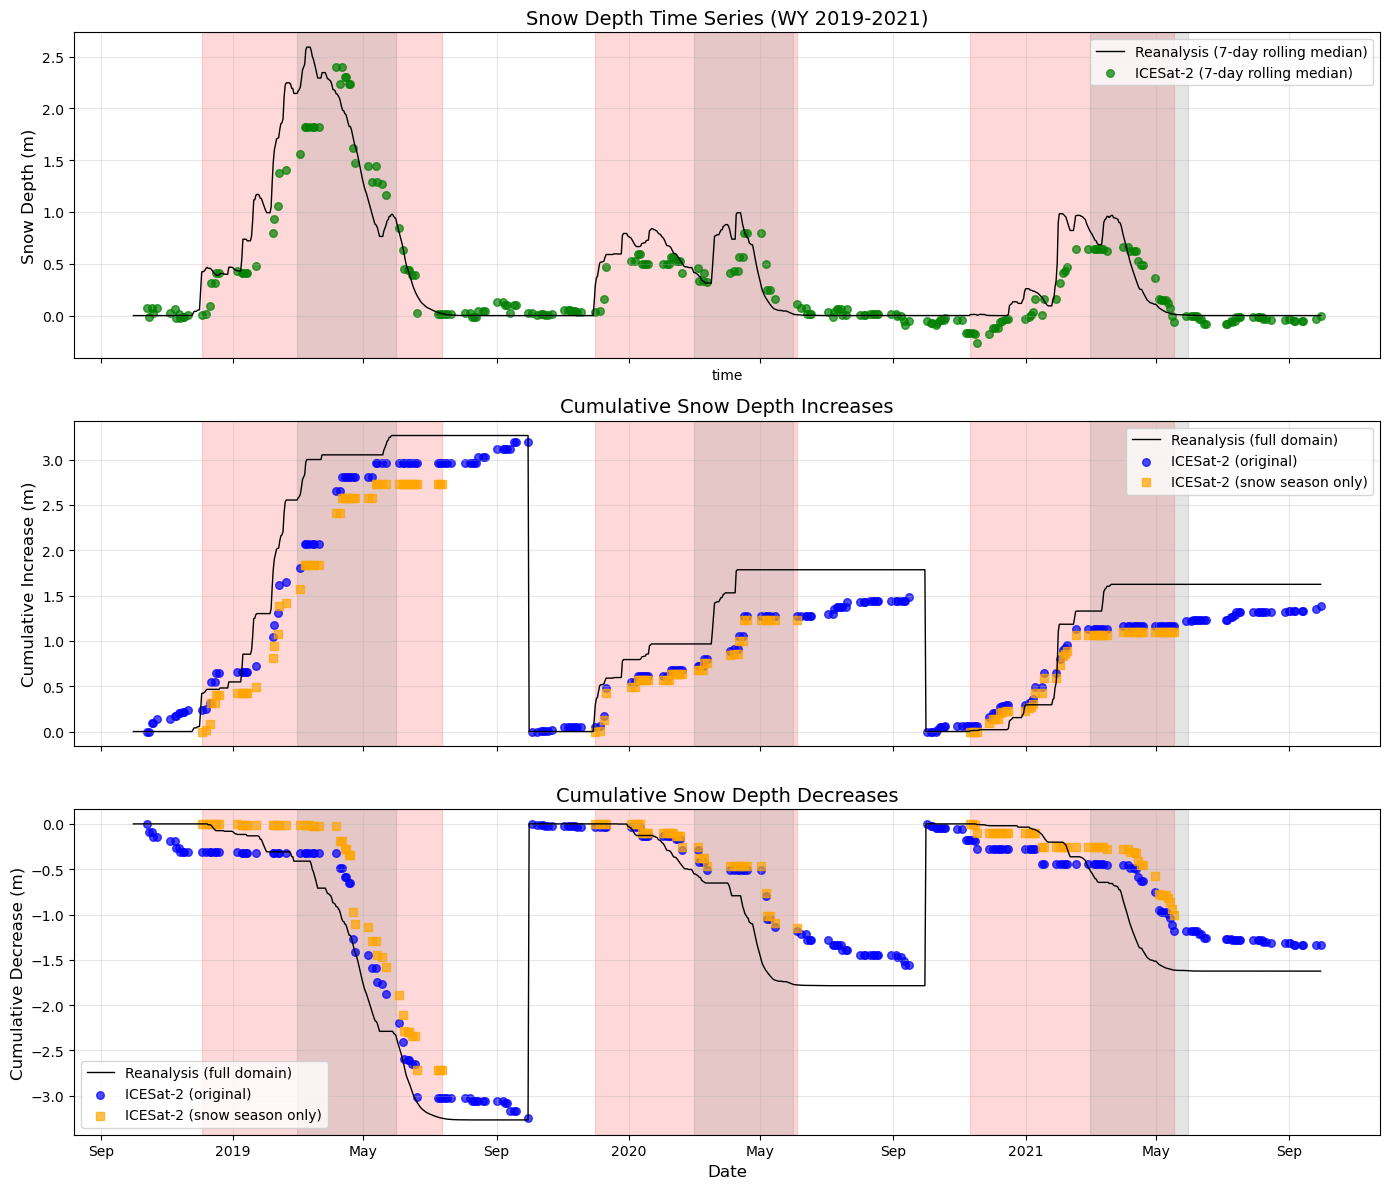

In [102]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

In [112]:
sd_rolling_7day_median

<xarray.DataArray 'sd_rolling_7day_median' (time: 13514)> Size: 54kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(13514,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

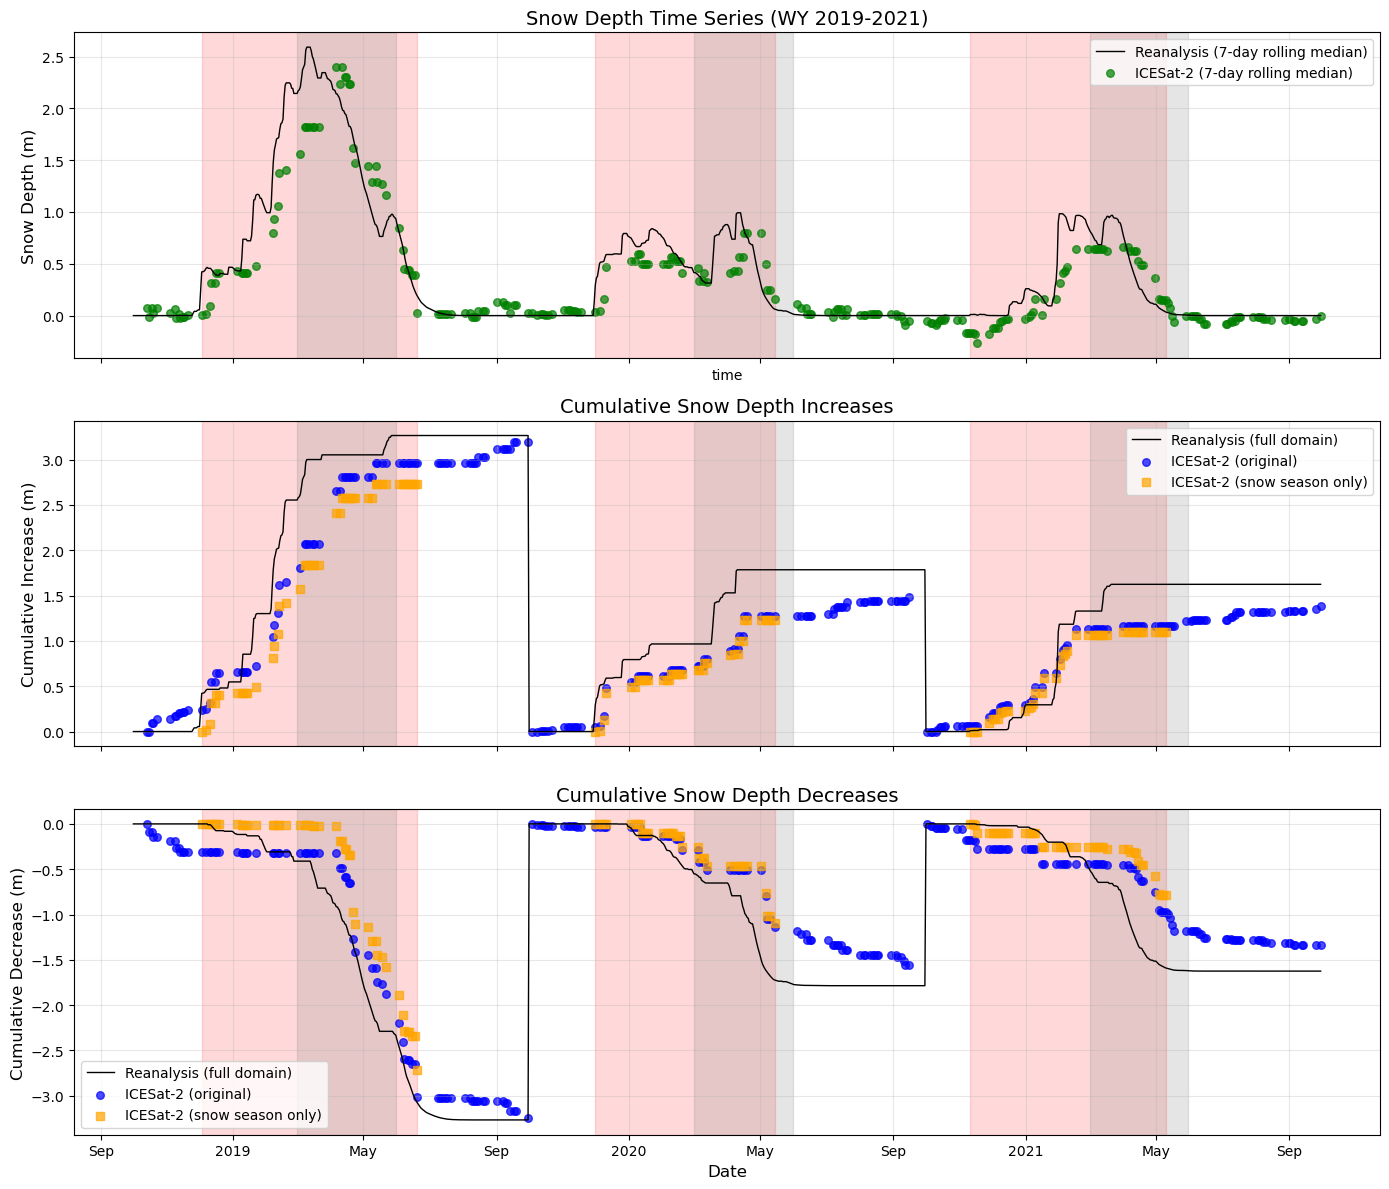

In [104]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

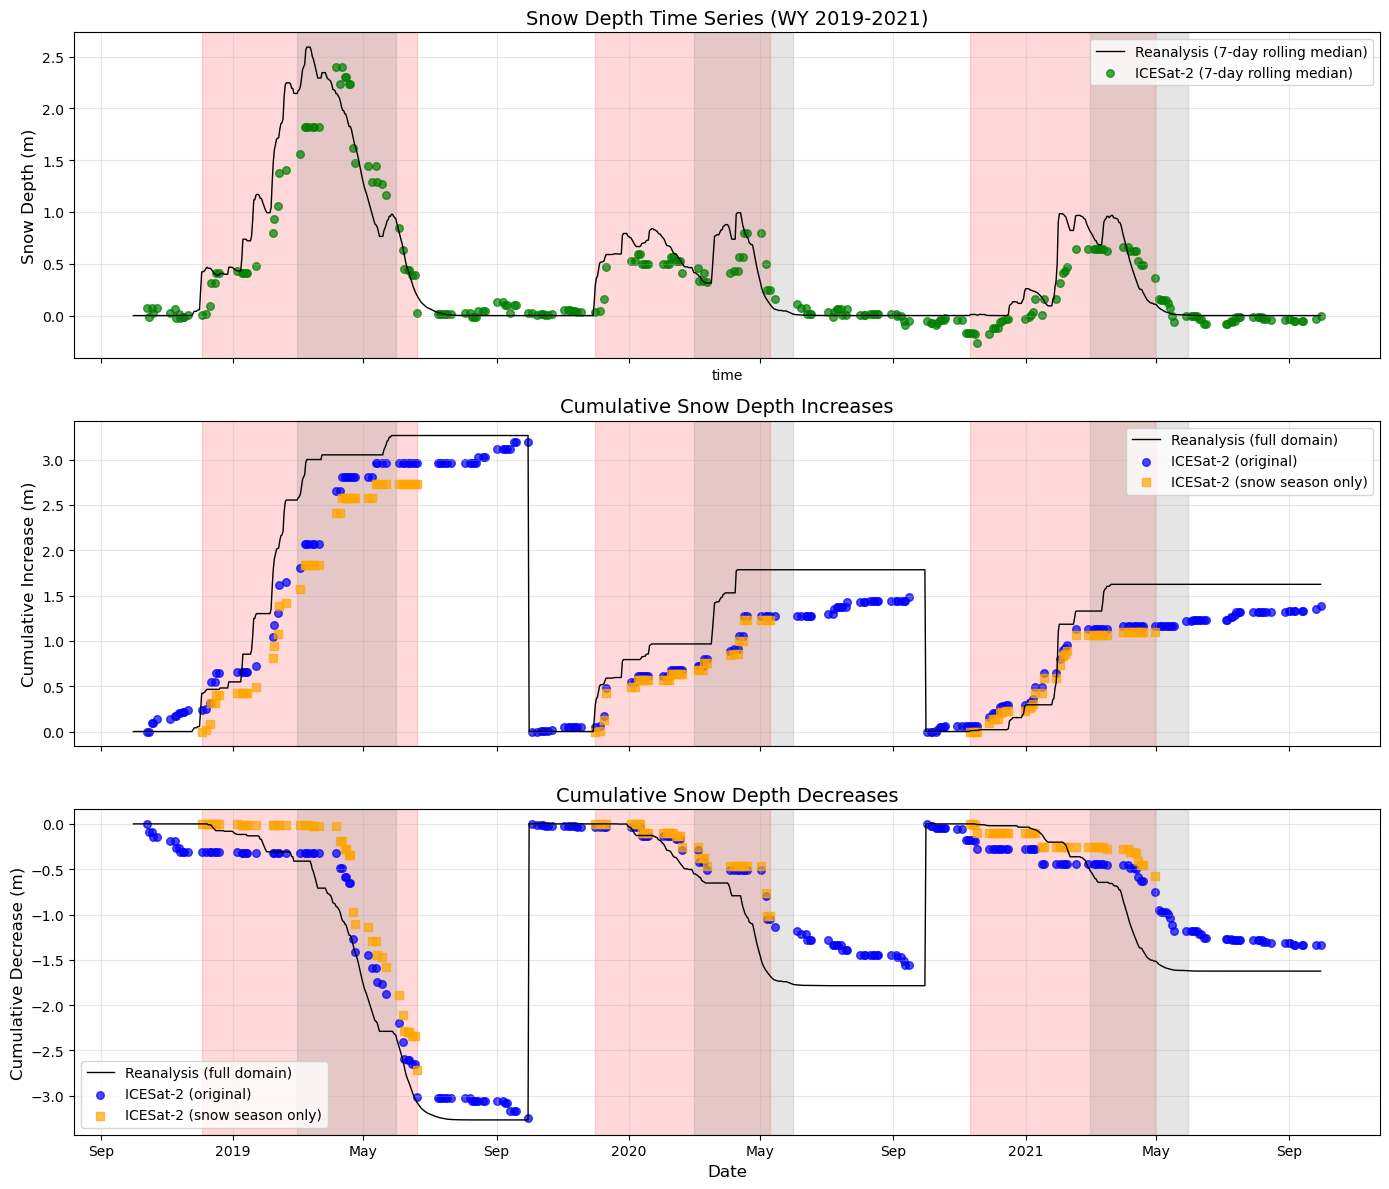

In [106]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

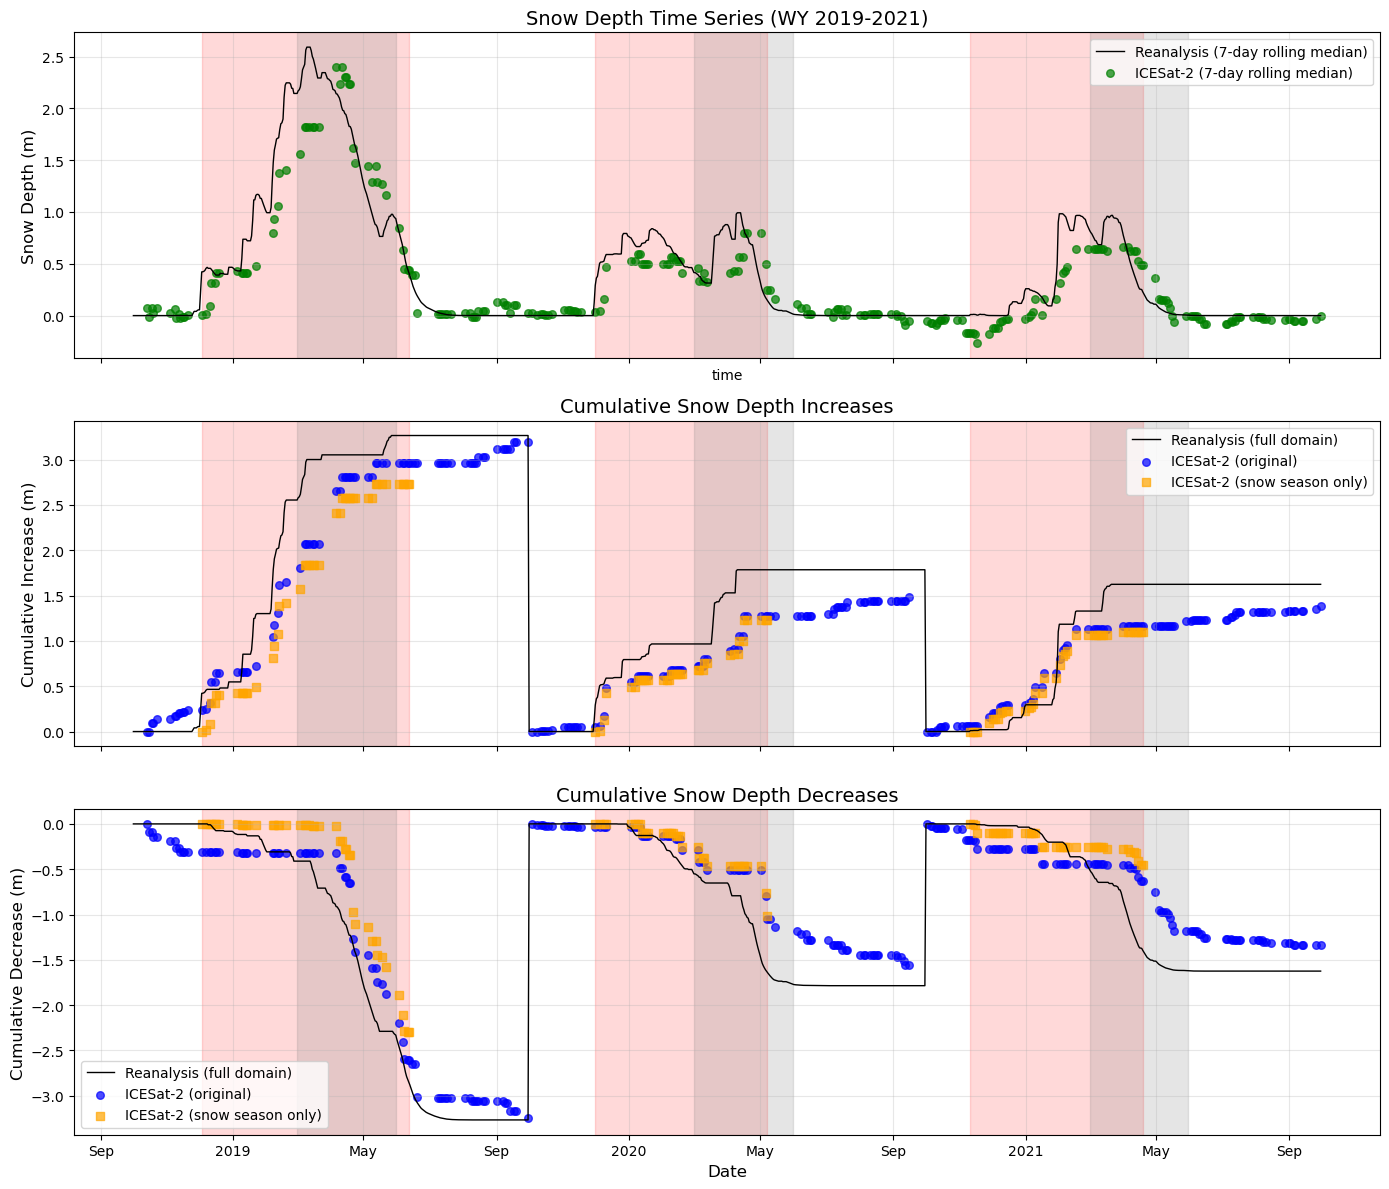

In [108]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

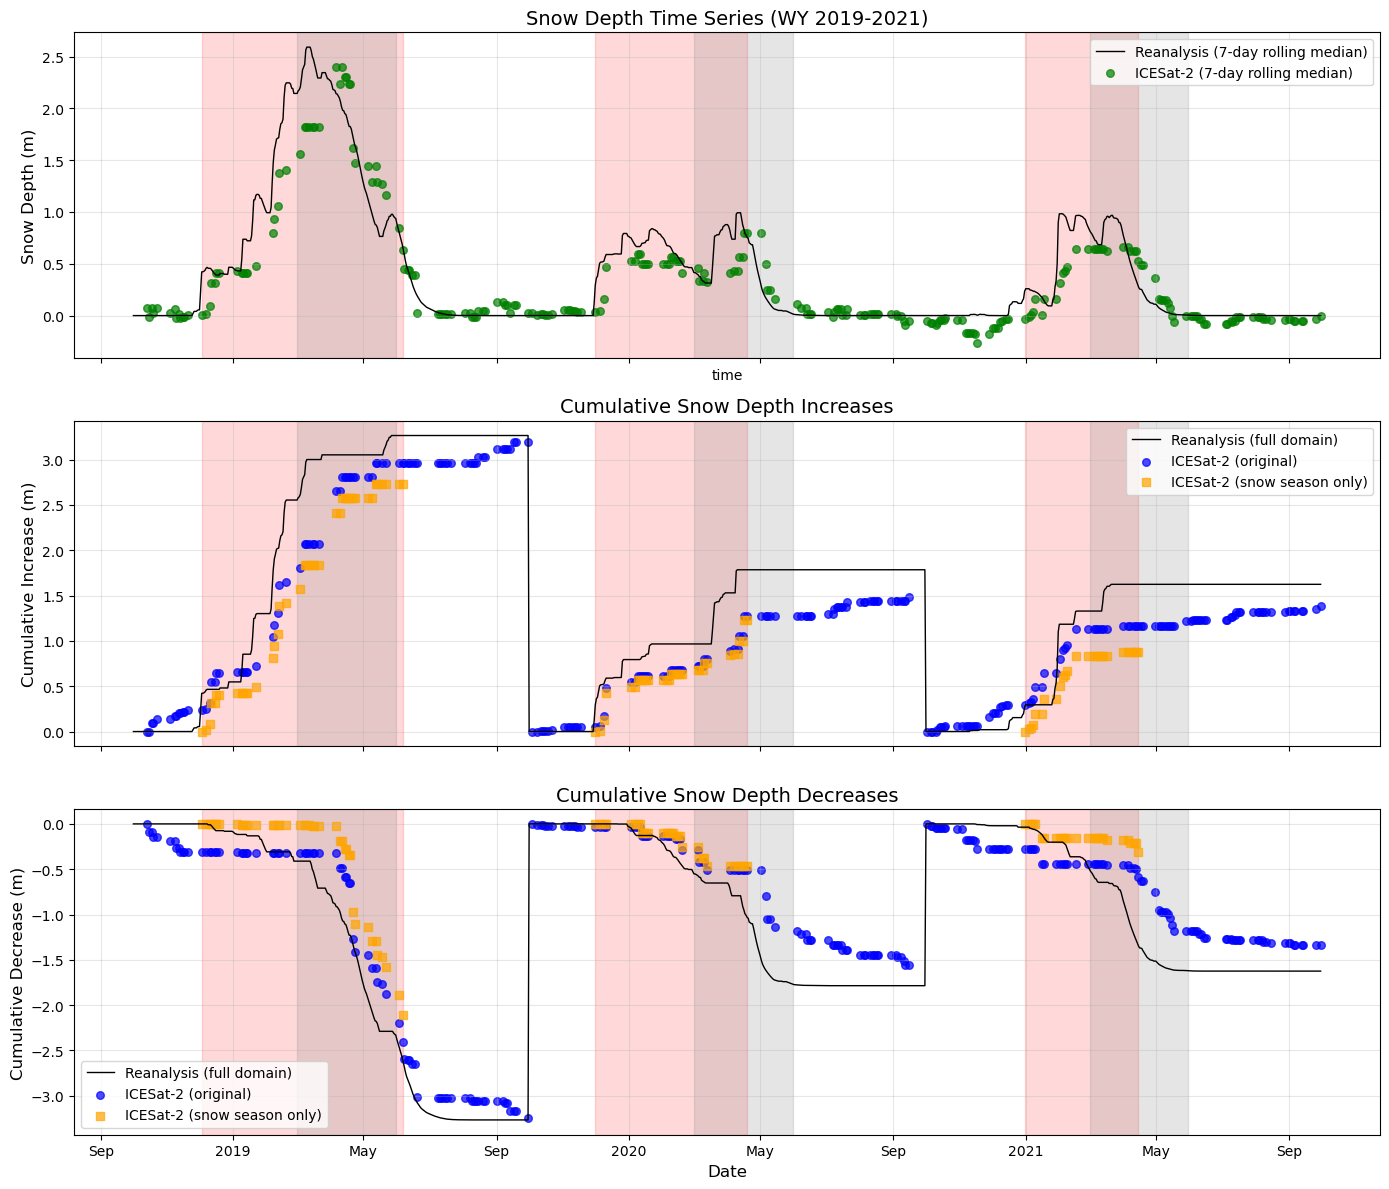

In [110]:
# Combined plot: Snow depth time series + cumulative increases/decreases with thresholding comparison

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top subplot: Snow depth time series
sd_rolling_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(
    ax=axes[0], color='k', linewidth=1, label='Reanalysis (7-day rolling median)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=30, alpha=0.7, c='green', label='ICESat-2 (7-day rolling median)')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('Snow Depth Time Series (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle subplot: Cumulative Increases - both methods
axes[1].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[1].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Increases', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Bottom subplot: Cumulative Decreases - both methods
axes[2].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_median_1week'], 
                s=30, alpha=0.7, c='blue', label='ICESat-2 (original)')
axes[2].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='orange', marker='s', label='ICESat-2 (snow season only)')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[2].set_title('Cumulative Snow Depth Decreases', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Add shaded regions for snow season (based on SCA threshold criteria)
for wy in [2019, 2020, 2021]:
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        snow_start = wy_data['date'].min()
        snow_end = wy_data['date'].max()
        for ax in axes:
            ax.axvspan(snow_start, snow_end, alpha=0.15, color='red', zorder=0, 
                       label='Snow season' if wy == 2019 else '')

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

### Make a new column to shift the dates:

In [39]:
sd_rolling_df

NameError: name 'sd_rolling_df' is not defined

In [44]:
# For sd_rolling_df - add a centered date column (3.5 days earlier)
sd_rolling_df['date_centered'] = sd_rolling_df['time'] - pd.Timedelta(days=3.5)

# For medians_both - add a centered date column (3.5 days earlier)
medians_both['date_centered'] = medians_both['date'] - pd.Timedelta(days=3.5)

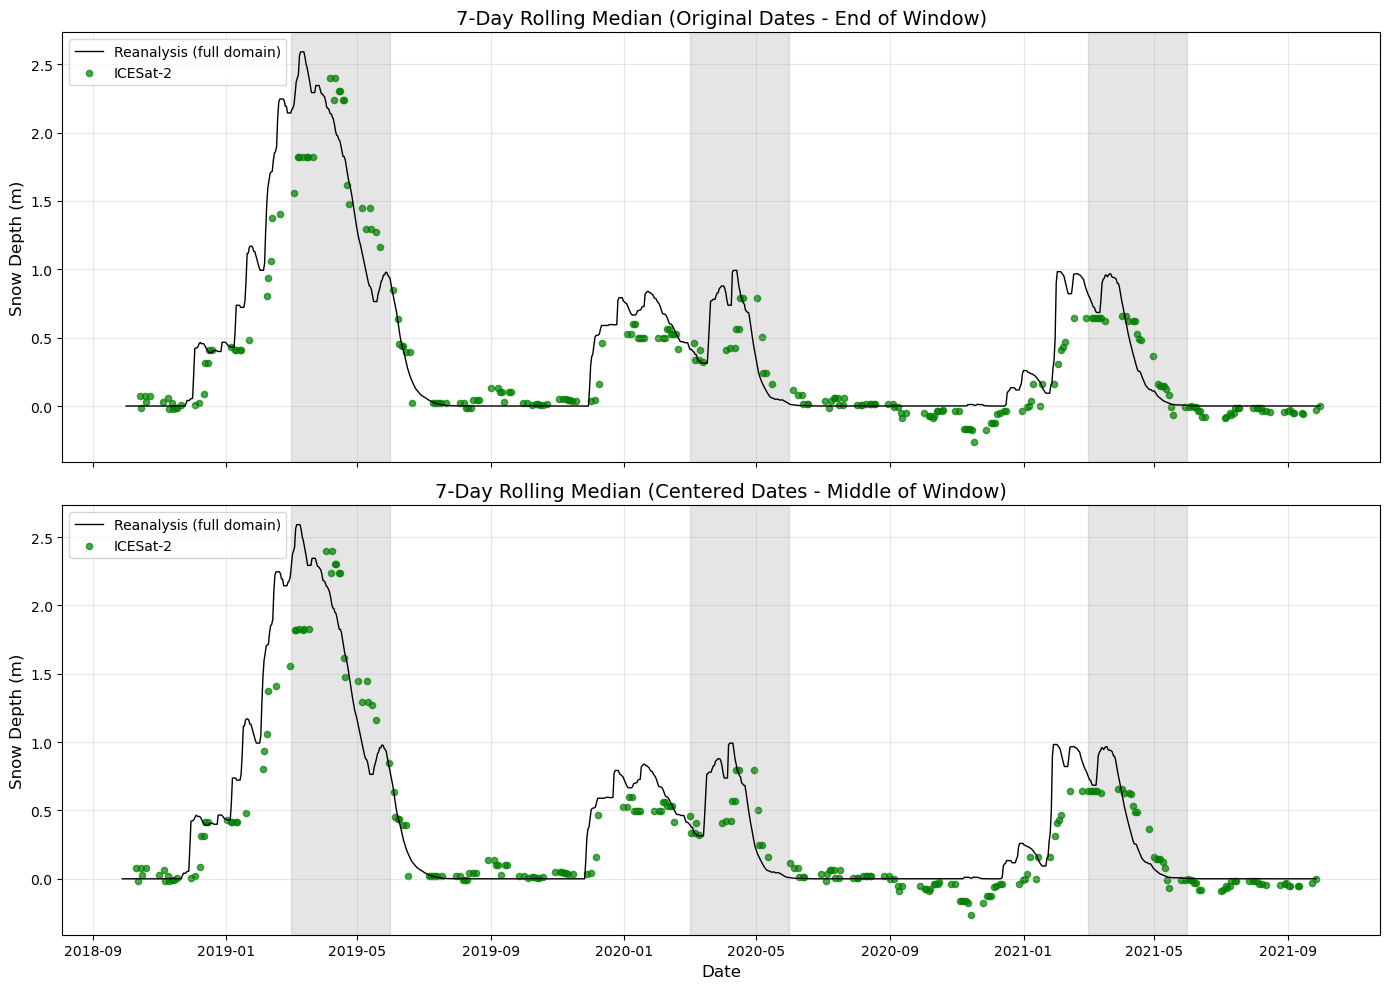

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sd_rolling_df_subset = sd_rolling_df[(sd_rolling_df['time'] >= '2018-10-01') & 
                                      (sd_rolling_df['time'] <= '2021-09-30')]

# Top plot: Original dates (trailing window)
axes[0].plot(sd_rolling_df_subset['time'], sd_rolling_df_subset['sd_rolling_7day_median'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[0].scatter(medians_both['date'], medians_both['running_median_1week'], 
                s=20, alpha=0.7, c='green', label='ICESat-2')
axes[0].set_ylabel('Snow Depth (m)', fontsize=12)
axes[0].set_title('7-Day Rolling Median (Original Dates - End of Window)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom plot: Centered dates
axes[1].plot(sd_rolling_df_subset['date_centered'], sd_rolling_df_subset['sd_rolling_7day_median'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date_centered'], medians_both['running_median_1week'], 
                s=20, alpha=0.7, c='green', label='ICESat-2')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Snow Depth (m)', fontsize=12)
axes[1].set_title('7-Day Rolling Median (Centered Dates - Middle of Window)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

In [115]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,water_year,daily_change_median_1week,increase_median_1week,decrease_median_1week,cumulative_increase_median_1week,cumulative_decrease_median_1week,sca_rolling_7day_median,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season
0,0.075891,0.0,2018-10-14,0.075891,0.0,2019,NaN,NaN,NaN,0.000000,0.000000,0.052785,False,NaN,NaN,NaN,NaN,NaN
1,-0.108008,0.0,2018-10-15,-0.016058,0.0,2019,-0.091949,0.000000,-0.091949,0.000000,-0.091949,0.043546,False,NaN,NaN,NaN,NaN,NaN
2,0.093040,0.0,2018-10-18,0.075891,0.0,2019,0.091949,0.091949,0.000000,0.091949,-0.091949,0.020042,False,NaN,NaN,NaN,NaN,NaN
3,-0.018844,0.0,2018-10-19,0.028523,0.0,2019,-0.047368,0.000000,-0.047368,0.091949,-0.139317,0.016110,False,NaN,NaN,NaN,NaN,NaN
4,0.122762,0.0,2018-10-23,0.075891,0.0,2019,0.047368,0.047368,0.000000,0.139317,-0.139317,0.014465,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000060,False,NaN,NaN,NaN,NaN,NaN
256,-0.000564,0.0,2021-09-13,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000054,False,NaN,NaN,NaN,NaN,NaN
257,-0.055093,0.0,2021-09-14,-0.055093,0.0,2021,-0.002486,0.000000,-0.002486,1.332635,-1.337789,0.000053,False,NaN,NaN,NaN,NaN,NaN
258,0.138069,0.0,2021-09-26,-0.031074,0.0,2021,0.024019,0.024019,0.000000,1.356654,-1.337789,0.000047,False,NaN,NaN,NaN,NaN,NaN


In [113]:
sd_rolling_df

,time,spatial_ref,sd_rolling_7day_median,water_year,daily_change,increase,decrease,cumulative_increase,cumulative_decrease
0,1984-10-01,0,0.0,1985,NaN,NaN,NaN,0.0000,0.0000
1,1984-10-02,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000
2,1984-10-03,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000
3,1984-10-04,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000
4,1984-10-05,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
13509,2021-09-26,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246
13510,2021-09-27,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246
13511,2021-09-28,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246
13512,2021-09-29,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246


In [46]:
# Calculate differences between ICESat-2 cumulative values and reanalysis analog dates
# For each ICESat-2 date, find all dates in sd_rolling_df within ±7 days (centered 2-week window)
# across ALL years in the reanalysis record

WINDOW_DAYS = 7  # ±7 days = 2-week centered window

# Add day-of-year to both dataframes for matching
sd_rolling_df['doy'] = sd_rolling_df['time'].dt.dayofyear
medians_both['doy'] = medians_both['date'].dt.dayofyear

# Dictionary to store results: key = ICESat-2 date, value = DataFrame of analog comparisons
analog_differences = {}

# Only process dates that are in snow season, have valid cumulative values, and are between March 1 and May 31
valid_is2_dates = medians_both[
    (medians_both['in_snow_season']) &
    (medians_both['cumulative_increase_snow_season'].notna()) &
    (medians_both['date'].dt.month >= 3) & (medians_both['date'].dt.month <= 5)
].copy()

for idx, row in valid_is2_dates.iterrows():
    is2_date = row['date']
    is2_doy = row['doy']
    is2_cum_increase = row['cumulative_increase_snow_season']
    is2_cum_decrease = row['cumulative_decrease_snow_season']
    is2_wy = row['water_year']
    
    # Find all dates in sd_rolling_df within ±WINDOW_DAYS of the same day-of-year
    # Handle year-end wraparound (e.g., DOY 360 should match DOY 5)
    doy_diff = (sd_rolling_df['doy'] - is2_doy).abs()
    doy_diff_wrapped = 365 - doy_diff  # For wraparound cases
    within_window = (doy_diff <= WINDOW_DAYS) | (doy_diff_wrapped <= WINDOW_DAYS)
    
    analog_dates = sd_rolling_df[within_window].copy()
    
    if len(analog_dates) > 0:
        # Calculate differences
        analog_dates['is2_date'] = is2_date
        analog_dates['is2_water_year'] = is2_wy
        analog_dates['is2_cum_increase'] = is2_cum_increase
        analog_dates['is2_cum_decrease'] = is2_cum_decrease
        analog_dates['diff_cum_increase'] = is2_cum_increase - analog_dates['cumulative_increase']
        analog_dates['diff_cum_decrease'] = is2_cum_decrease - analog_dates['cumulative_decrease']
        analog_dates['doy_offset'] = analog_dates['doy'] - is2_doy  # Days from target DOY
        
        # Store in dictionary
        analog_differences[is2_date] = analog_dates[['time', 'water_year', 'doy', 'doy_offset',
                                                      'sd_rolling_7day_median', 
                                                      'cumulative_increase', 'cumulative_decrease',
                                                      'is2_date', 'is2_water_year',
                                                      'is2_cum_increase', 'is2_cum_decrease',
                                                      'diff_cum_increase', 'diff_cum_decrease']].copy()

print(f"Created analog comparisons for {len(analog_differences)} ICESat-2 dates (March 1 - May 31, snow season)")
print(f"Example: {list(analog_differences.keys())[0]} has {len(analog_differences[list(analog_differences.keys())[0]])} analog dates")

Created analog comparisons for 46 ICESat-2 dates (March 1 - May 31, snow season)
Example: 2019-03-04 00:00:00 has 555 analog dates


In [128]:
analog_differences

{Timestamp('2019-03-04 00:00:00'):             time  water_year  doy  doy_offset  sd_rolling_7day_median  \
 147   1985-02-25        1985   56          -7                  1.0858   
 148   1985-02-26        1985   57          -6                  1.0584   
 149   1985-02-27        1985   58          -5                  1.0326   
 150   1985-02-28        1985   59          -4                  1.0022   
 151   1985-03-01        1985   60          -3                  0.9736   
 ...          ...         ...  ...         ...                     ...   
 13306 2021-03-07        2021   66           3                  0.7208   
 13307 2021-03-08        2021   67           4                  0.6952   
 13308 2021-03-09        2021   68           5                  0.6844   
 13309 2021-03-10        2021   69           6                  0.6844   
 13310 2021-03-11        2021   70           7                  0.6844   
 
        cumulative_increase  cumulative_decrease   is2_date  is2_water_year 

In [129]:
analog_differences.keys()

dict_keys([Timestamp('2019-03-04 00:00:00'), Timestamp('2019-03-08 00:00:00'), Timestamp('2019-03-09 00:00:00'), Timestamp('2019-03-12 00:00:00'), Timestamp('2019-03-16 00:00:00'), Timestamp('2019-03-17 00:00:00'), Timestamp('2019-03-21 00:00:00'), Timestamp('2019-04-06 00:00:00'), Timestamp('2019-04-10 00:00:00'), Timestamp('2019-04-11 00:00:00'), Timestamp('2019-04-14 00:00:00'), Timestamp('2019-04-15 00:00:00'), Timestamp('2019-04-18 00:00:00'), Timestamp('2019-04-19 00:00:00'), Timestamp('2019-04-22 00:00:00'), Timestamp('2019-04-23 00:00:00'), Timestamp('2019-05-05 00:00:00'), Timestamp('2019-05-09 00:00:00'), Timestamp('2019-05-13 00:00:00'), Timestamp('2019-05-14 00:00:00'), Timestamp('2019-05-18 00:00:00'), Timestamp('2019-05-22 00:00:00'), Timestamp('2020-03-05 00:00:00'), Timestamp('2020-03-06 00:00:00'), Timestamp('2020-03-09 00:00:00'), Timestamp('2020-03-10 00:00:00'), Timestamp('2020-03-13 00:00:00'), Timestamp('2020-04-03 00:00:00'), Timestamp('2020-04-07 00:00:00'), Tim

In [130]:
analog_differences.values()

dict_values([            time  water_year  doy  doy_offset  sd_rolling_7day_median  \
147   1985-02-25        1985   56          -7                  1.0858   
148   1985-02-26        1985   57          -6                  1.0584   
149   1985-02-27        1985   58          -5                  1.0326   
150   1985-02-28        1985   59          -4                  1.0022   
151   1985-03-01        1985   60          -3                  0.9736   
...          ...         ...  ...         ...                     ...   
13306 2021-03-07        2021   66           3                  0.7208   
13307 2021-03-08        2021   67           4                  0.6952   
13308 2021-03-09        2021   68           5                  0.6844   
13309 2021-03-10        2021   69           6                  0.6844   
13310 2021-03-11        2021   70           7                  0.6844   

       cumulative_increase  cumulative_decrease   is2_date  is2_water_year  \
147                 1.8836      

In [114]:
37*14

518

In [47]:
# Example: Access analog comparison DataFrame for one ICESat-2 date
# Pick the first available ICESat-2 date in the dictionary
example_is2_date = list(analog_differences.keys())[0]
example_df = analog_differences[example_is2_date]

print(f"ICESat-2 date: {example_is2_date}")
display(example_df.head())

ICESat-2 date: 2019-03-04 00:00:00


,time,water_year,doy,doy_offset,sd_rolling_7day_median,cumulative_increase,cumulative_decrease,is2_date,is2_water_year,is2_cum_increase,is2_cum_decrease,diff_cum_increase,diff_cum_decrease
147,1985-02-25,1985,56,-7,1.0858,1.8836,-0.7978,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.781234
148,1985-02-26,1985,57,-6,1.0584,1.8836,-0.8252,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.808634
149,1985-02-27,1985,58,-5,1.0326,1.8836,-0.8510,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.834434
150,1985-02-28,1985,59,-4,1.0022,1.8836,-0.8814,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.864834
151,1985-03-01,1985,60,-3,0.9736,1.8836,-0.9100,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.893434


In [132]:
example_df

,time,water_year,doy,doy_offset,sd_rolling_7day_median,cumulative_increase,cumulative_decrease,is2_date,is2_water_year,is2_cum_increase,is2_cum_decrease,diff_cum_increase,diff_cum_decrease
147,1985-02-25,1985,56,-7,1.0858,1.8836,-0.7978,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.781234
148,1985-02-26,1985,57,-6,1.0584,1.8836,-0.8252,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.808634
149,1985-02-27,1985,58,-5,1.0326,1.8836,-0.8510,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.834434
150,1985-02-28,1985,59,-4,1.0022,1.8836,-0.8814,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.864834
151,1985-03-01,1985,60,-3,0.9736,1.8836,-0.9100,2019-03-04,2019,1.569802,-0.016566,-0.313798,0.893434
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13306,2021-03-07,2021,66,3,0.7208,1.3296,-0.6088,2019-03-04,2019,1.569802,-0.016566,0.240202,0.592234
13307,2021-03-08,2021,67,4,0.6952,1.3296,-0.6344,2019-03-04,2019,1.569802,-0.016566,0.240202,0.617834
13308,2021-03-09,2021,68,5,0.6844,1.3296,-0.6452,2019-03-04,2019,1.569802,-0.016566,0.240202,0.628634
13309,2021-03-10,2021,69,6,0.6844,1.3296,-0.6452,2019-03-04,2019,1.569802,-0.016566,0.240202,0.628634


In [48]:
# For each ICESat-2 date, find the 5 analog dates (from different water years, excluding the same WY as ICESat-2) with smallest difference in cumulative increase and decrease

best_analogs_increase = {}
best_analogs_decrease = {}

for is2_date, df in analog_differences.items():
    is2_wy = df['is2_water_year'].iloc[0]
    # Exclude analogs from the same water year as the ICESat-2 date
    df_filtered = df[df['water_year'] != is2_wy]
    # Sort by absolute difference for cumulative increase, drop duplicates by water year
    inc_sorted = df_filtered.sort_values('diff_cum_increase', key=lambda x: x.abs())
    inc_unique = inc_sorted.drop_duplicates(subset='water_year', keep='first')
    best_analogs_increase[is2_date] = inc_unique.head(5)
    
    # Sort by absolute difference for cumulative decrease, drop duplicates by water year
    dec_sorted = df_filtered.sort_values('diff_cum_decrease', key=lambda x: x.abs())
    dec_unique = dec_sorted.drop_duplicates(subset='water_year', keep='first')
    best_analogs_decrease[is2_date] = dec_unique.head(5)

# Example: show best analogs for the first ICESat-2 date
example_is2_date = list(analog_differences.keys())[0]
print(f"Best 5 analogs for cumulative increase (date: {example_is2_date}):")
display(best_analogs_increase[example_is2_date])
print(f"Best 5 analogs for cumulative decrease (date: {example_is2_date}):")
display(best_analogs_decrease[example_is2_date])

Best 5 analogs for cumulative increase (date: 2019-03-04 00:00:00):


,time,water_year,doy,doy_offset,sd_rolling_7day_median,cumulative_increase,cumulative_decrease,is2_date,is2_water_year,is2_cum_increase,is2_cum_decrease,diff_cum_increase,diff_cum_decrease
1976,1990-02-28,1990,59,-4,1.0164,1.5728,-0.5564,2019-03-04,2019,1.569802,-0.016566,-0.002998,0.539834
1249,1988-03-03,1988,63,0,0.7682,1.5590,-0.7908,2019-03-04,2019,1.569802,-0.016566,0.010802,0.774234
5625,2000-02-25,2000,56,-7,1.4984,1.5560,-0.0576,2019-03-04,2019,1.569802,-0.016566,0.013802,0.041034
10388,2013-03-11,2013,70,7,0.8498,1.5398,-0.6900,2019-03-04,2019,1.569802,-0.016566,0.030002,0.673434
5991,2001-02-25,2001,56,-7,1.1574,1.6278,-0.4704,2019-03-04,2019,1.569802,-0.016566,-0.057998,0.453834


Best 5 analogs for cumulative decrease (date: 2019-03-04 00:00:00):


,time,water_year,doy,doy_offset,sd_rolling_7day_median,cumulative_increase,cumulative_decrease,is2_date,is2_water_year,is2_cum_increase,is2_cum_decrease,diff_cum_increase,diff_cum_decrease
5634,2000-03-05,2000,65,2,1.8196,1.8772,-0.0576,2019-03-04,2019,1.569802,-0.016566,-0.307398,0.041034
881,1987-03-01,1987,60,-3,0.7928,0.9548,-0.1624,2019-03-04,2019,1.569802,-0.016566,0.615002,0.145834
12205,2018-03-02,2018,61,-2,0.1044,0.3040,-0.1996,2019-03-04,2019,1.569802,-0.016566,1.265802,0.183034
10008,2012-02-25,2012,56,-7,0.3584,0.6036,-0.2452,2019-03-04,2019,1.569802,-0.016566,0.966202,0.228634
4899,1998-03-01,1998,60,-3,2.4864,2.7500,-0.2636,2019-03-04,2019,1.569802,-0.016566,-1.180198,0.247034


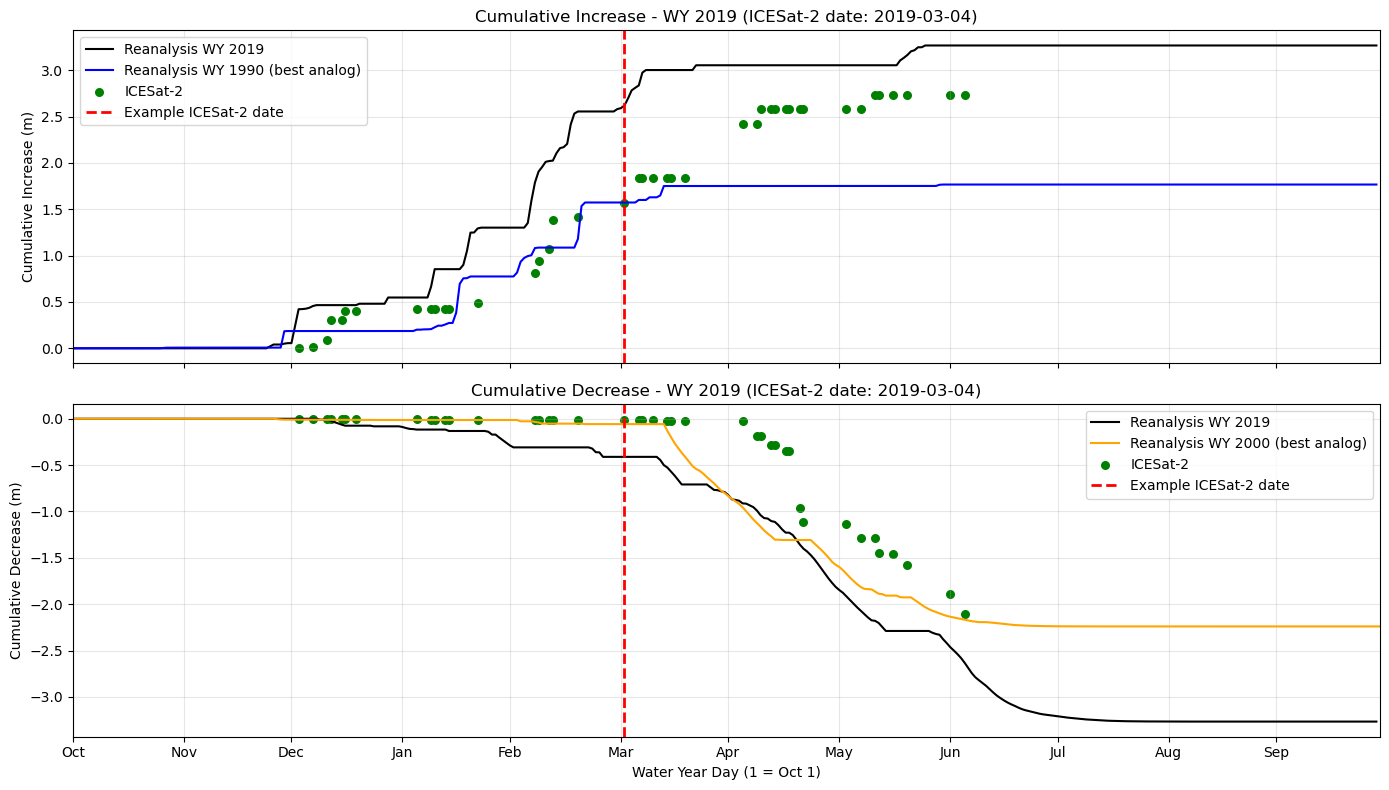

In [49]:
# Plot WY cumulative increases/decreases for an example ICESat-2 date and best analogs
import matplotlib.dates as mdates

# Pick an example ICESat-2 date
example_is2_date = list(best_analogs_increase.keys())[0]
example_is2_row = medians_both[medians_both['date'] == example_is2_date].iloc[0]
wy_is2 = example_is2_row['water_year']

# Get best analog WYs for increase and decrease
best_inc_wy = best_analogs_increase[example_is2_date].iloc[0]['water_year']
best_dec_wy = best_analogs_decrease[example_is2_date].iloc[0]['water_year']

# Get time series for each
# ICESat-2 for its WY
is2_wy_df = medians_both[medians_both['water_year'] == wy_is2].copy()
# Reanalysis for each WY
re_wy_is2 = sd_rolling_df[sd_rolling_df['water_year'] == wy_is2].copy()
re_wy_inc = sd_rolling_df[sd_rolling_df['water_year'] == best_inc_wy].copy()
re_wy_dec = sd_rolling_df[sd_rolling_df['water_year'] == best_dec_wy].copy()

# Function to get water year day (1 = Oct 1, 365 = Sep 30)
def get_wy_day(date):
    # Water year starts Oct 1
    wy_start = pd.Timestamp(year=date.year if date.month < 10 else date.year, month=10, day=1)
    if date.month < 10:
        wy_start = pd.Timestamp(year=date.year-1, month=10, day=1)
    return (date - wy_start).days + 1

# Add water year day columns for overlaying years
for df in [is2_wy_df, re_wy_is2, re_wy_inc, re_wy_dec]:
    if 'date' in df:
        df['wy_day'] = df['date'].apply(get_wy_day)
    else:
        df['wy_day'] = df['time'].apply(get_wy_day)

# Get the wy_day for the example ICESat-2 date
example_wy_day = get_wy_day(example_is2_date)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cumulative Increase
axes[0].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_increase'], label=f'Reanalysis WY {wy_is2}', color='k')
axes[0].plot(re_wy_inc['wy_day'], re_wy_inc['cumulative_increase'], label=f'Reanalysis WY {best_inc_wy} (best analog)', color='blue')
axes[0].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_increase_snow_season'], label='ICESat-2', color='green', s=30)
axes[0].axvline(example_wy_day, color='red', linestyle='--', linewidth=2, label='Example ICESat-2 date')
axes[0].set_ylabel('Cumulative Increase (m)')
axes[0].set_title(f'Cumulative Increase - WY {wy_is2} (ICESat-2 date: {example_is2_date.date()})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative Decrease
axes[1].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_decrease'], label=f'Reanalysis WY {wy_is2}', color='k')
axes[1].plot(re_wy_dec['wy_day'], re_wy_dec['cumulative_decrease'], label=f'Reanalysis WY {best_dec_wy} (best analog)', color='orange')
axes[1].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_decrease_snow_season'], label='ICESat-2', color='green', s=30)
axes[1].axvline(example_wy_day, color='red', linestyle='--', linewidth=2, label='Example ICESat-2 date')
axes[1].set_ylabel('Cumulative Decrease (m)')
axes[1].set_title(f'Cumulative Decrease - WY {wy_is2} (ICESat-2 date: {example_is2_date.date()})')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[1].set_xlabel('Water Year Day (1 = Oct 1)')
axes[1].set_xlim(1, 366)
axes[1].set_xticks([1, 32, 62, 93, 123, 154, 184, 215, 246, 276, 307, 337])
axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
plt.tight_layout()
plt.show()

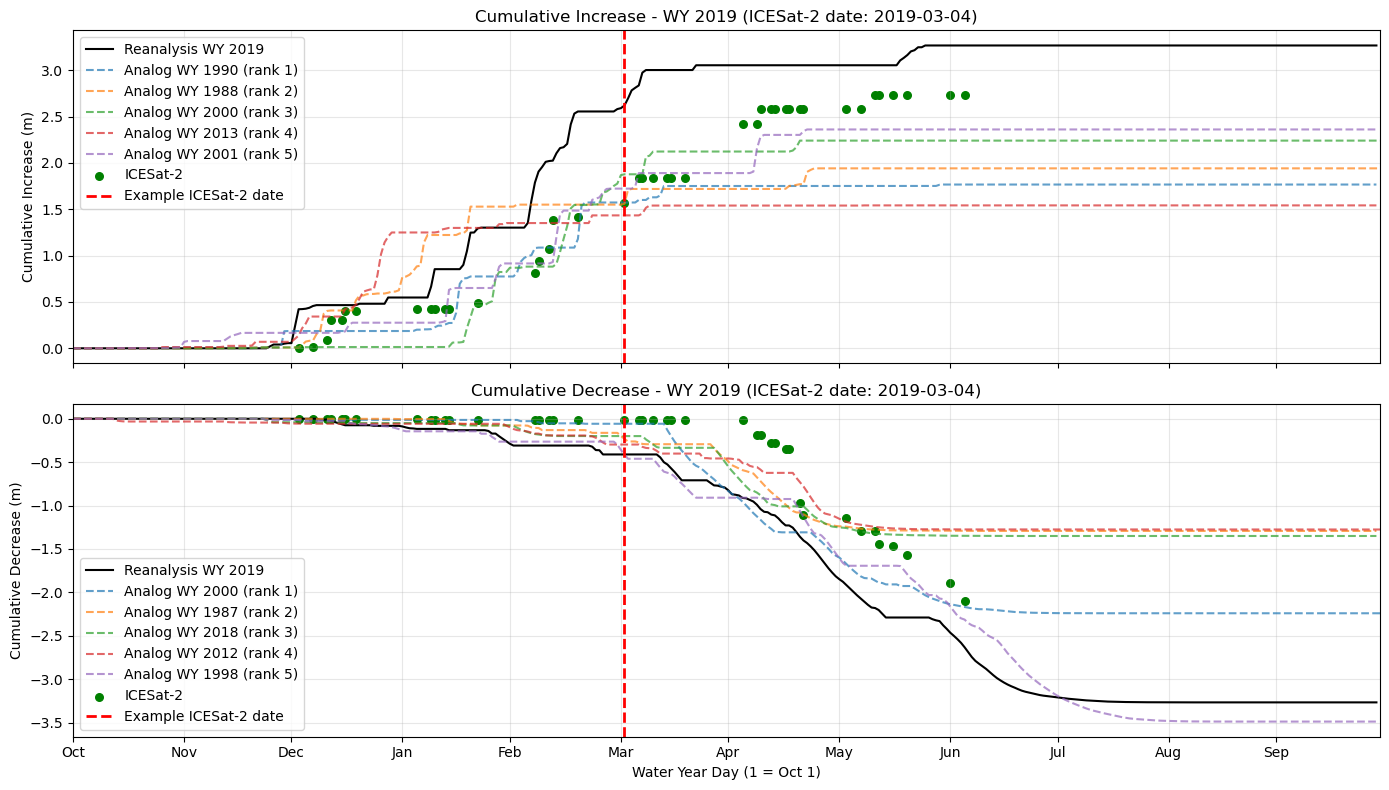

In [50]:
# Plot WY cumulative increases/decreases for an example ICESat-2 date and all top 5 analog years, with rank labels
import matplotlib.dates as mdates

# Pick an example ICESat-2 date
example_is2_date = list(best_analogs_increase.keys())[0]
example_is2_row = medians_both[medians_both['date'] == example_is2_date].iloc[0]
wy_is2 = example_is2_row['water_year']

# Get best analog WYs and their ranks for increase and decrease (all top 5)
best_inc_analogs = best_analogs_increase[example_is2_date].reset_index(drop=True)
best_dec_analogs = best_analogs_decrease[example_is2_date].reset_index(drop=True)
best_inc_wys = best_inc_analogs['water_year'].values
best_dec_wys = best_dec_analogs['water_year'].values

# Get time series for each
is2_wy_df = medians_both[medians_both['water_year'] == wy_is2].copy()
re_wy_is2 = sd_rolling_df[sd_rolling_df['water_year'] == wy_is2].copy()
re_wy_incs = [sd_rolling_df[sd_rolling_df['water_year'] == wy].copy() for wy in best_inc_wys]
re_wy_decs = [sd_rolling_df[sd_rolling_df['water_year'] == wy].copy() for wy in best_dec_wys]

# Function to get water year day (1 = Oct 1, 365 = Sep 30)
def get_wy_day(date):
    wy_start = pd.Timestamp(year=date.year if date.month < 10 else date.year, month=10, day=1)
    if date.month < 10:
        wy_start = pd.Timestamp(year=date.year-1, month=10, day=1)
    return (date - wy_start).days + 1

# Add water year day columns for overlaying years
for df in [is2_wy_df, re_wy_is2] + re_wy_incs + re_wy_decs:
    if 'date' in df:
        df['wy_day'] = df['date'].apply(get_wy_day)
    else:
        df['wy_day'] = df['time'].apply(get_wy_day)

example_wy_day = get_wy_day(example_is2_date)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cumulative Increase
axes[0].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_increase'], label=f'Reanalysis WY {wy_is2}', color='k')
for i, (wy, df) in enumerate(zip(best_inc_wys, re_wy_incs)):
    rank = i + 1
    axes[0].plot(df['wy_day'], df['cumulative_increase'], label=f'Analog WY {wy} (rank {rank})', linestyle='--', alpha=0.7)
axes[0].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_increase_snow_season'], label='ICESat-2', color='green', s=30)
axes[0].axvline(example_wy_day, color='red', linestyle='--', linewidth=2, label='Example ICESat-2 date')
axes[0].set_ylabel('Cumulative Increase (m)')
axes[0].set_title(f'Cumulative Increase - WY {wy_is2} (ICESat-2 date: {example_is2_date.date()})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative Decrease
axes[1].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_decrease'], label=f'Reanalysis WY {wy_is2}', color='k')
for i, (wy, df) in enumerate(zip(best_dec_wys, re_wy_decs)):
    rank = i + 1
    axes[1].plot(df['wy_day'], df['cumulative_decrease'], label=f'Analog WY {wy} (rank {rank})', linestyle='--', alpha=0.7)
axes[1].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_decrease_snow_season'], label='ICESat-2', color='green', s=30)
axes[1].axvline(example_wy_day, color='red', linestyle='--', linewidth=2, label='Example ICESat-2 date')
axes[1].set_ylabel('Cumulative Decrease (m)')
axes[1].set_title(f'Cumulative Decrease - WY {wy_is2} (ICESat-2 date: {example_is2_date.date()})')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[1].set_xlabel('Water Year Day (1 = Oct 1)')
axes[1].set_xlim(1, 366)
axes[1].set_xticks([1, 32, 62, 93, 123, 154, 184, 215, 246, 276, 307, 337])
axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
plt.tight_layout()
plt.show()

In [145]:
sd_rolling_df

,time,spatial_ref,sd_rolling_7day_median,water_year,daily_change,increase,decrease,cumulative_increase,cumulative_decrease,doy
0,1984-10-01,0,0.0,1985,NaN,NaN,NaN,0.0000,0.0000,275
1,1984-10-02,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000,276
2,1984-10-03,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000,277
3,1984-10-04,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000,278
4,1984-10-05,0,0.0,1985,0.0,0.0,0.0,0.0000,0.0000,279
...,...,...,...,...,...,...,...,...,...,...
13509,2021-09-26,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246,269
13510,2021-09-27,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246,270
13511,2021-09-28,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246,271
13512,2021-09-29,0,0.0,2021,0.0,0.0,0.0,1.6246,-1.6246,272


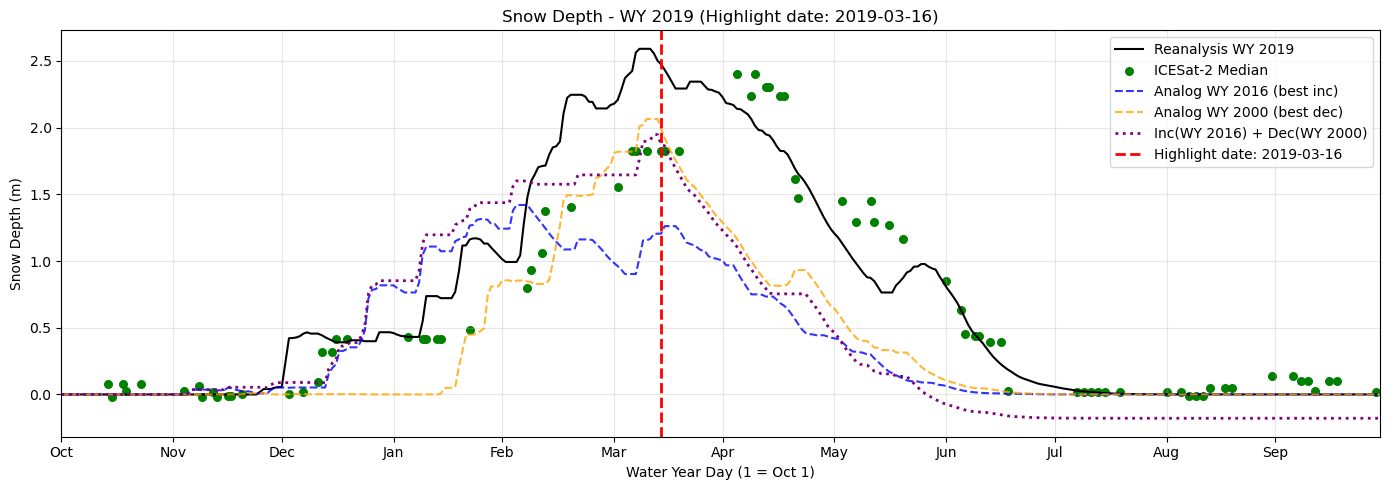

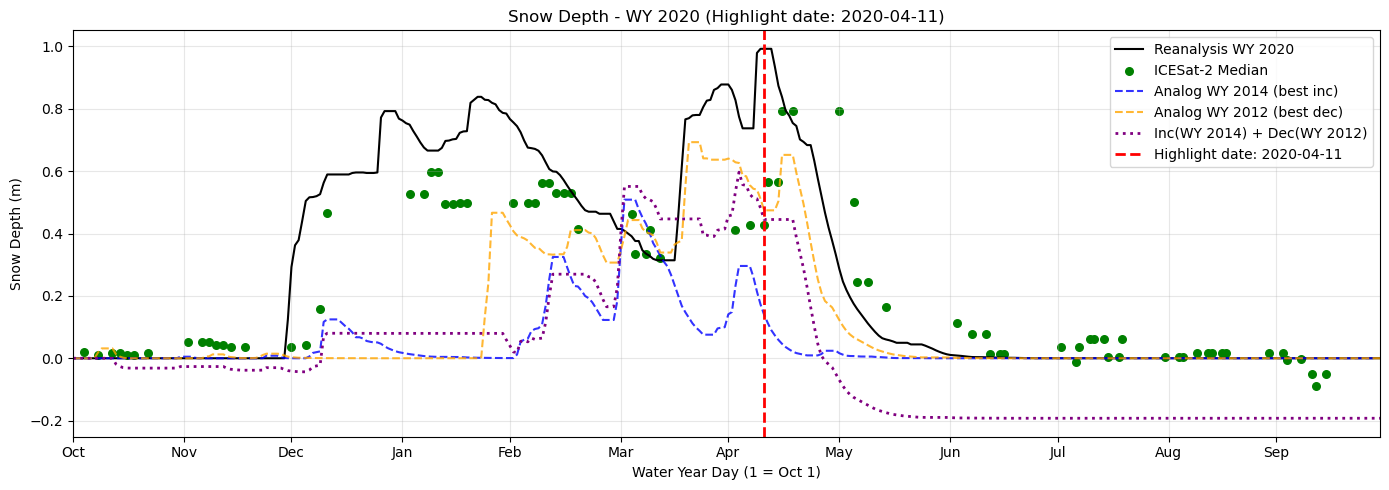

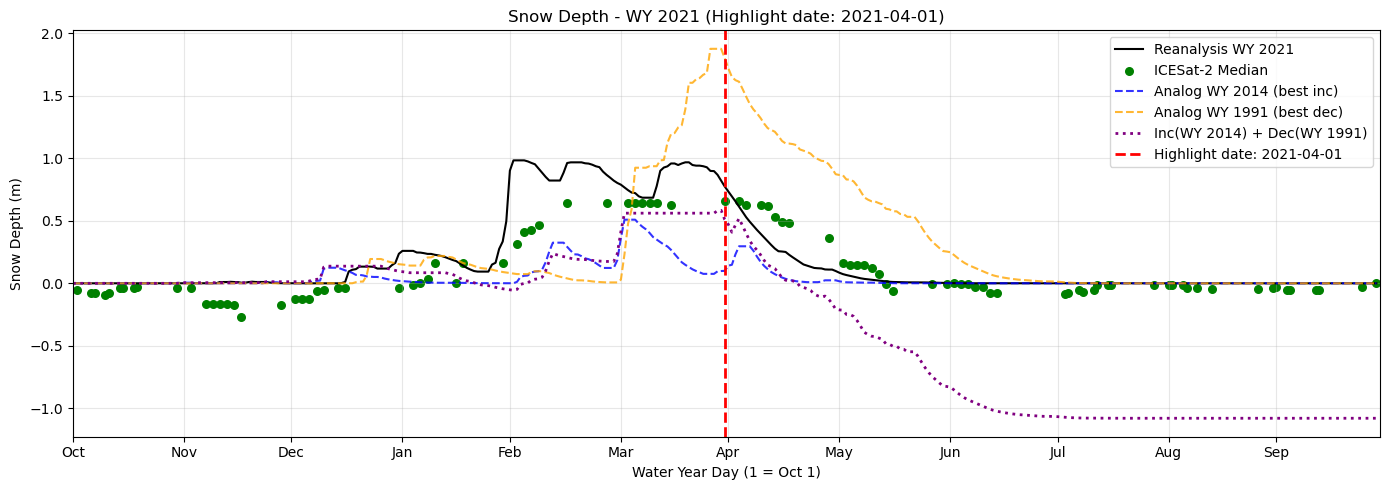

In [52]:
# Plot for highlight dates: 2019-03-16, 2020-04-11, 2021-04-01
highlight_dates = [pd.Timestamp('2019-03-16'), pd.Timestamp('2020-04-11'), pd.Timestamp('2021-04-01')]

for highlight_date in highlight_dates:
    # Water year: if month < 10, water year is current year; else, year + 1
    wy_is2 = highlight_date.year if highlight_date.month < 10 else highlight_date.year + 1
    example_is2_date = highlight_date
    example_wy_day = (highlight_date - pd.Timestamp(year=wy_is2-1, month=10, day=1)).days + 1

    best_inc_wy = best_analogs_increase[example_is2_date].iloc[0]['water_year']
    best_dec_wy = best_analogs_decrease[example_is2_date].iloc[0]['water_year']

    # Reanalysis snow depth for WY of highlight date
    re_wy_is2 = sd_rolling_df[sd_rolling_df['water_year'] == wy_is2].copy()
    # ICESat-2 medians for that WY
    is2_wy_df = medians_both[medians_both['water_year'] == wy_is2].copy()
    # Reanalysis snow depth for best analog WYs
    re_wy_inc = sd_rolling_df[sd_rolling_df['water_year'] == best_inc_wy].copy()
    re_wy_dec = sd_rolling_df[sd_rolling_df['water_year'] == best_dec_wy].copy()

    def get_wy_day(date):
        wy_start = pd.Timestamp(year=date.year if date.month < 10 else date.year, month=10, day=1)
        if date.month < 10:
            wy_start = pd.Timestamp(year=date.year-1, month=10, day=1)
        return (date - wy_start).days + 1

    for df in [is2_wy_df, re_wy_is2, re_wy_inc, re_wy_dec]:
        if 'date' in df:
            df['wy_day'] = df['date'].apply(get_wy_day)
        else:
            df['wy_day'] = df['time'].apply(get_wy_day)

    # Align cumulative increase from best inc WY and cumulative decrease from best dec WY
    combo = pd.DataFrame({'wy_day': range(1, 367)})
    combo = combo.merge(re_wy_inc[['wy_day', 'cumulative_increase']], on='wy_day', how='left')
    combo = combo.merge(re_wy_dec[['wy_day', 'cumulative_decrease']], on='wy_day', how='left')
    combo['cumulative_increase'] = combo['cumulative_increase'].interpolate()
    combo['cumulative_decrease'] = combo['cumulative_decrease'].interpolate()
    combo['inc_plus_dec'] = combo['cumulative_increase'] + combo['cumulative_decrease']

    fig, ax = plt.subplots(figsize=(14, 5))
    # Plot reanalysis snow depth for WY of highlight date
    ax.plot(re_wy_is2['wy_day'], re_wy_is2['sd_rolling_7day_median'], label=f'Reanalysis WY {wy_is2}', color='k')
    # Plot ICESat-2 medians for that WY
    ax.scatter(is2_wy_df['wy_day'], is2_wy_df['running_median_1week'], label='ICESat-2 Median', color='green', s=30)
    # Plot reanalysis snow depth for best analog WYs
    ax.plot(re_wy_inc['wy_day'], re_wy_inc['sd_rolling_7day_median'], label=f'Analog WY {best_inc_wy} (best inc)', linestyle='--', color='blue', alpha=0.8)
    ax.plot(re_wy_dec['wy_day'], re_wy_dec['sd_rolling_7day_median'], label=f'Analog WY {best_dec_wy} (best dec)', linestyle='--', color='orange', alpha=0.8)
    # Plot cumulative increase from best inc WY + cumulative decrease from best dec WY
    ax.plot(combo['wy_day'], combo['inc_plus_dec'], label=f'Inc(WY {best_inc_wy}) + Dec(WY {best_dec_wy})', linestyle=':', color='purple', linewidth=2)
    # Vertical dashed line at highlight date
    ax.axvline(example_wy_day, color='red', linestyle='--', linewidth=2, label=f'Highlight date: {highlight_date.date()}')
    ax.set_xlabel('Water Year Day (1 = Oct 1)')
    ax.set_ylabel('Snow Depth (m)')
    ax.set_title(f'Snow Depth - WY {wy_is2} (Highlight date: {highlight_date.date()})')
    ax.set_xlim(1, 366)
    ax.set_xticks([1, 32, 62, 93, 123, 154, 184, 215, 246, 276, 307, 337])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [67]:
# Plot cumulative increase/decrease for highlight dates with top 5 analogs
import matplotlib.dates as mdates

highlight_dates = [pd.Timestamp('2019-03-16'), pd.Timestamp('2020-04-11'), pd.Timestamp('2021-04-01')]

# Function to get water year day (1 = Oct 1, 365 = Sep 30)
def get_wy_day(date):
    wy_start = pd.Timestamp(year=date.year if date.month < 10 else date.year, month=10, day=1)
    if date.month < 10:
        wy_start = pd.Timestamp(year=date.year-1, month=10, day=1)
    return (date - wy_start).days + 1

for highlight_date in highlight_dates:
    # Get water year for this highlight date
    wy_is2 = highlight_date.year if highlight_date.month < 10 else highlight_date.year + 1
    
    # Get best analog WYs and their ranks for increase and decrease (all top 5)
    best_inc_analogs = best_analogs_increase[highlight_date].reset_index(drop=True)
    best_dec_analogs = best_analogs_decrease[highlight_date].reset_index(drop=True)
    best_inc_wys = best_inc_analogs['water_year'].values
    best_dec_wys = best_dec_analogs['water_year'].values
    
    # Get time series for each
    is2_wy_df = medians_both[medians_both['water_year'] == wy_is2].copy()
    re_wy_is2 = sd_rolling_df[sd_rolling_df['water_year'] == wy_is2].copy()
    re_wy_incs = [sd_rolling_df[sd_rolling_df['water_year'] == wy].copy() for wy in best_inc_wys]
    re_wy_decs = [sd_rolling_df[sd_rolling_df['water_year'] == wy].copy() for wy in best_dec_wys]
    
    # Add water year day columns for overlaying years
    for df in [is2_wy_df, re_wy_is2] + re_wy_incs + re_wy_decs:
        if 'date' in df.columns:
            df['wy_day'] = df['date'].apply(get_wy_day)
        else:
            df['wy_day'] = df['time'].apply(get_wy_day)
    
    highlight_wy_day = get_wy_day(highlight_date)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Cumulative Increase
    axes[0].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_increase'], label=f'Reanalysis WY {wy_is2}', color='k')
    for i, (wy, df) in enumerate(zip(best_inc_wys, re_wy_incs)):
        rank = i + 1
        axes[0].plot(df['wy_day'], df['cumulative_increase'], label=f'Analog WY {wy} (rank {rank})', linestyle='--', alpha=0.7)
    axes[0].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_increase_snow_season'], label='ICESat-2', color='green', s=30)
    axes[0].axvline(highlight_wy_day, color='red', linestyle='--', linewidth=2, label='Highlight date')
    axes[0].set_ylabel('Cumulative Increase (m)')
    axes[0].set_title(f'Cumulative Increase - WY {wy_is2} (Highlight date: {highlight_date.date()})')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Cumulative Decrease
    axes[1].plot(re_wy_is2['wy_day'], re_wy_is2['cumulative_decrease'], label=f'Reanalysis WY {wy_is2}', color='k')
    for i, (wy, df) in enumerate(zip(best_dec_wys, re_wy_decs)):
        rank = i + 1
        axes[1].plot(df['wy_day'], df['cumulative_decrease'], label=f'Analog WY {wy} (rank {rank})', linestyle='--', alpha=0.7)
    axes[1].scatter(is2_wy_df['wy_day'], is2_wy_df['cumulative_decrease_snow_season'], label='ICESat-2', color='green', s=30)
    axes[1].axvline(highlight_wy_day, color='red', linestyle='--', linewidth=2, label='Highlight date')
    axes[1].set_ylabel('Cumulative Decrease (m)')
    axes[1].set_title(f'Cumulative Decrease - WY {wy_is2} (Highlight date: {highlight_date.date()})')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    axes[1].set_xlabel('Water Year Day (1 = Oct 1)')
    axes[1].set_xlim(1, 366)
    axes[1].set_xticks([1, 32, 62, 93, 123, 154, 184, 215, 246, 276, 307, 337])
    axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
    plt.tight_layout()
    plt.show()

KeyError: 'water_year'

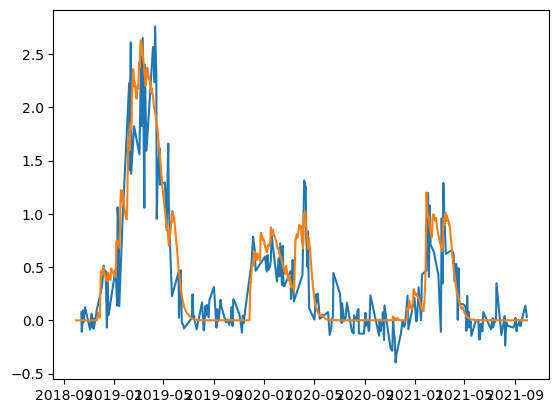

In [63]:
fig, ax = plt.subplots()

ax.plot(medians_both['date'], medians_both['icesat2_3dep_dif'])
ax.plot(median_sd_allyrs['time'].sel(time=slice('2018-10-01','2021-09-30')), median_sd_allyrs.sel(time=slice('2018-10-01','2021-09-30')))

In [60]:
median_sd_allyrs

<xarray.DataArray 'SD_Post' (time: 13514)> Size: 54kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(13514,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

In [64]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,water_year,daily_change_median_1week,increase_median_1week,decrease_median_1week,cumulative_increase_median_1week,cumulative_decrease_median_1week,sca_rolling_7day_median,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season,date_centered,doy
0,0.075891,0.0,2018-10-14,0.075891,0.0,2019,NaN,NaN,NaN,0.000000,0.000000,0.052785,False,NaN,NaN,NaN,NaN,NaN,2018-10-10 12:00:00,287
1,-0.108008,0.0,2018-10-15,-0.016058,0.0,2019,-0.091949,0.000000,-0.091949,0.000000,-0.091949,0.043546,False,NaN,NaN,NaN,NaN,NaN,2018-10-11 12:00:00,288
2,0.093040,0.0,2018-10-18,0.075891,0.0,2019,0.091949,0.091949,0.000000,0.091949,-0.091949,0.020042,False,NaN,NaN,NaN,NaN,NaN,2018-10-14 12:00:00,291
3,-0.018844,0.0,2018-10-19,0.028523,0.0,2019,-0.047368,0.000000,-0.047368,0.091949,-0.139317,0.016110,False,NaN,NaN,NaN,NaN,NaN,2018-10-15 12:00:00,292
4,0.122762,0.0,2018-10-23,0.075891,0.0,2019,0.047368,0.047368,0.000000,0.139317,-0.139317,0.014465,False,NaN,NaN,NaN,NaN,NaN,2018-10-19 12:00:00,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000060,False,NaN,NaN,NaN,NaN,NaN,2021-09-02 12:00:00,249
256,-0.000564,0.0,2021-09-13,-0.052606,0.0,2021,0.000000,0.000000,0.000000,1.332635,-1.335303,0.000054,False,NaN,NaN,NaN,NaN,NaN,2021-09-09 12:00:00,256
257,-0.055093,0.0,2021-09-14,-0.055093,0.0,2021,-0.002486,0.000000,-0.002486,1.332635,-1.337789,0.000053,False,NaN,NaN,NaN,NaN,NaN,2021-09-10 12:00:00,257
258,0.138069,0.0,2021-09-26,-0.031074,0.0,2021,0.024019,0.024019,0.000000,1.356654,-1.337789,0.000047,False,NaN,NaN,NaN,NaN,NaN,2021-09-22 12:00:00,269


### Calculate the cumulative increases and decreases for the median values, no rolling window:

In [42]:
# Look up SCA values for each ICESat-2 date from the daily SCA time series
# Use .sel with method='nearest' to handle any slight date mismatches
medians_both['mean_sca_area_weighted'] = medians_both['date'].apply(
    lambda d: float(mean_sca_area_weighted.sel(time=d, method='nearest').values)
)

# Assign water year if not already done
if 'water_year' not in medians_both.columns:
    medians_both['water_year'] = medians_both['date'].apply(
        lambda x: x.year + 1 if x.month >= 10 else x.year
    )

# Thresholds
SCA_THRESHOLD = 0.5  # SCA must be > 0.05 to be considered "in snow season"
SUSTAINED_DAYS = 14  # Must stay above threshold for 2 weeks before counting

# Drop any existing snow season columns to avoid _x/_y suffixes on re-run
cols_to_drop = [col for col in medians_both.columns if 'snow_season' in col]
if cols_to_drop:
    medians_both = medians_both.drop(columns=cols_to_drop)

# Create a mask for valid snow season dates using the daily SCA data
def get_snow_season_mask(group):
    """
    For each water year:
    - Start when SCA stays > threshold for more than 2 weeks
    - End when SCA < threshold after April 1
    """
    group = group.sort_values('date').copy()
    wy = group['water_year'].iloc[0]
    april_1 = pd.Timestamp(year=wy, month=4, day=1)
    
    # Get the daily SCA data for this water year to check sustained periods
    wy_start = pd.Timestamp(year=wy-1, month=10, day=1)
    wy_end = pd.Timestamp(year=wy, month=9, day=30)
    
    sca_wy = mean_sca_area_weighted.sel(time=slice(wy_start, wy_end))
    sca_times = pd.to_datetime(sca_wy.time.values)
    sca_values = sca_wy.values
    
    # Find the first date where SCA stays above threshold for SUSTAINED_DAYS
    above_threshold = sca_values > SCA_THRESHOLD
    first_sustained_date = None
    
    for i in range(len(above_threshold)):
        if above_threshold[i]:
            # Check if it stays above threshold for SUSTAINED_DAYS
            end_check = min(i + SUSTAINED_DAYS, len(above_threshold))
            if all(above_threshold[i:end_check]) and (end_check - i) >= SUSTAINED_DAYS:
                first_sustained_date = sca_times[i]  # Start at beginning of sustained period
                break
    
    if first_sustained_date is None:
        group['in_snow_season'] = False
        return group
    
    # Find first date after April 1 with SCA < threshold (snow off)
    after_april1_mask = sca_times >= april_1
    below_threshold_after_april = after_april1_mask & (sca_values < SCA_THRESHOLD)
    
    if below_threshold_after_april.any():
        first_snow_off_date = sca_times[np.argmax(below_threshold_after_april)]
    else:
        first_snow_off_date = None
    
    # Apply mask to ICESat-2 dates
    if first_snow_off_date is not None:
        group['in_snow_season'] = (group['date'] >= first_sustained_date) & (group['date'] < first_snow_off_date)
    else:
        group['in_snow_season'] = (group['date'] >= first_sustained_date)
    
    return group

# Apply the snow season mask by water year
medians_both = medians_both.groupby('water_year', group_keys=False).apply(get_snow_season_mask)

# Now calculate cumulative changes only for dates in snow season
medians_snow_season = medians_both[medians_both['in_snow_season']].copy()

# Calculate daily changes within snow season using original icesat2_3dep_dif values
medians_snow_season['daily_change_snow_season'] = medians_snow_season.groupby('water_year')['icesat2_3dep_dif'].diff()

# Separate increases and decreases
medians_snow_season['increase_snow_season'] = medians_snow_season['daily_change_snow_season'].clip(lower=0)
medians_snow_season['decrease_snow_season'] = medians_snow_season['daily_change_snow_season'].clip(upper=0)

# Calculate cumulative sums within each water year
medians_snow_season['cumulative_increase_snow_season'] = medians_snow_season.groupby('water_year')['increase_snow_season'].cumsum()
medians_snow_season['cumulative_decrease_snow_season'] = medians_snow_season.groupby('water_year')['decrease_snow_season'].cumsum()

# Fill NaN values with 0
medians_snow_season['cumulative_increase_snow_season'] = medians_snow_season['cumulative_increase_snow_season'].fillna(0)
medians_snow_season['cumulative_decrease_snow_season'] = medians_snow_season['cumulative_decrease_snow_season'].fillna(0)

# Merge the new snow season columns back to medians_both
new_cols = ['daily_change_snow_season', 'increase_snow_season', 'decrease_snow_season', 
            'cumulative_increase_snow_season', 'cumulative_decrease_snow_season']

medians_both = medians_both.merge(
    medians_snow_season[['date'] + new_cols],
    on='date',
    how='left'
)

print(f"Snow season dates per water year (SCA > {SCA_THRESHOLD} sustained for {SUSTAINED_DAYS} days):")
for wy in sorted(medians_both['water_year'].unique()):
    wy_data = medians_both[(medians_both['water_year'] == wy) & (medians_both['in_snow_season'])]
    if len(wy_data) > 0:
        print(f"  WY {wy}: {wy_data['date'].min().strftime('%Y-%m-%d')} to {wy_data['date'].max().strftime('%Y-%m-%d')} ({len(wy_data)} dates)")

Snow season dates per water year (SCA > 0.5 sustained for 14 days):
  WY 2019: 2018-12-03 to 2019-06-03 (41 dates)
  WY 2020: 2019-12-01 to 2020-04-19 (33 dates)
  WY 2021: 2020-12-14 to 2021-04-11 (26 dates)


In [43]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,running_median_1week,reanalysis_running_median_1week,mean_sca_area_weighted,water_year,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season
0,0.075891,0.0,2018-10-14,0.075891,0.0,0.021475,2019,False,NaN,NaN,NaN,NaN,NaN
1,-0.108008,0.0,2018-10-15,-0.016058,0.0,0.020042,2019,False,NaN,NaN,NaN,NaN,NaN
2,0.093040,0.0,2018-10-18,0.075891,0.0,0.013644,2019,False,NaN,NaN,NaN,NaN,NaN
3,-0.018844,0.0,2018-10-19,0.028523,0.0,0.012853,2019,False,NaN,NaN,NaN,NaN,NaN
4,0.122762,0.0,2018-10-23,0.075891,0.0,0.015295,2019,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,-0.052606,0.0,0.000055,2021,False,NaN,NaN,NaN,NaN,NaN
256,-0.000564,0.0,2021-09-13,-0.052606,0.0,0.000049,2021,False,NaN,NaN,NaN,NaN,NaN
257,-0.055093,0.0,2021-09-14,-0.055093,0.0,0.000048,2021,False,NaN,NaN,NaN,NaN,NaN
258,0.138069,0.0,2021-09-26,-0.031074,0.0,0.000047,2021,False,NaN,NaN,NaN,NaN,NaN


### Calculate the cumulative increases and decreases of the Reanalysis snow depth for each water year:

In [140]:
# Convert DataArray to DataFrame for easier manipulation
sd_df = median_sd_allyrs.to_dataframe(name='median_sd').reset_index()

# Assign water year (WY starts Oct 1 of previous year, ends Sep 30 of current year)
sd_df['water_year'] = sd_df['time'].apply(
    lambda x: x.year + 1 if x.month >= 10 else x.year
)

# Sort by time to ensure proper ordering
sd_df = sd_df.sort_values('time').reset_index(drop=True)

# Calculate daily changes in median_sd
sd_df['daily_change'] = sd_df.groupby('water_year')['median_sd'].diff()

# Separate increases (positive changes) and decreases (negative changes)
sd_df['increase'] = sd_df['daily_change'].clip(lower=0)
sd_df['decrease'] = sd_df['daily_change'].clip(upper=0)

# Calculate cumulative sums within each water year
sd_df['cumulative_increase'] = sd_df.groupby('water_year')['increase'].cumsum()
sd_df['cumulative_decrease'] = sd_df.groupby('water_year')['decrease'].cumsum()

# Fill NaN values (first day of each water year) with 0
sd_df['cumulative_increase'] = sd_df['cumulative_increase'].fillna(0)
sd_df['cumulative_decrease'] = sd_df['cumulative_decrease'].fillna(0)

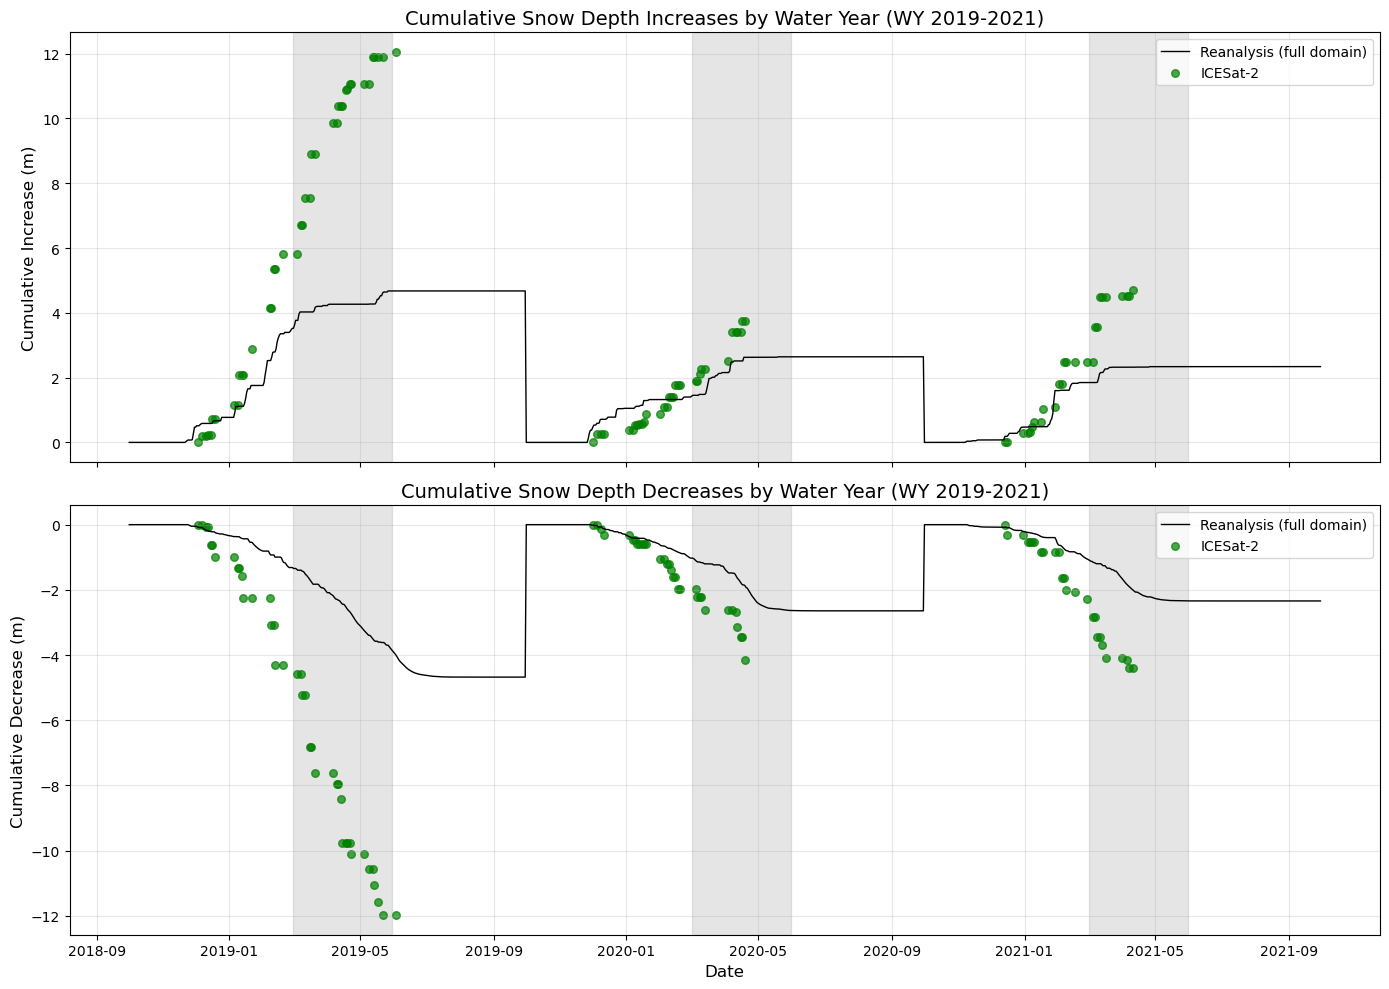

In [72]:
# Filter reanalysis data to ICESat-2 period
sd_df_subset = sd_df[(sd_df['time'] >= '2018-10-01') & 
                      (sd_df['time'] <= '2021-09-30')]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot cumulative increase
axes[0].plot(sd_df_subset['time'], sd_df_subset['cumulative_increase'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[0].scatter(medians_both['date'], medians_both['cumulative_increase_snow_season'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[0].set_ylabel('Cumulative Increase (m)', fontsize=12)
axes[0].set_title('Cumulative Snow Depth Increases by Water Year (WY 2019-2021)', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot cumulative decrease
axes[1].plot(sd_df_subset['time'], sd_df_subset['cumulative_decrease'], 
             color='k', linewidth=1, label='Reanalysis (full domain)')
axes[1].scatter(medians_both['date'], medians_both['cumulative_decrease_snow_season'], 
                s=30, alpha=0.7, c='green', label='ICESat-2')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Cumulative Decrease (m)', fontsize=12)
axes[1].set_title('Cumulative Snow Depth Decreases by Water Year (WY 2019-2021)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add shaded regions for March 1 - May 31
for year in [2019, 2020, 2021]:
    for ax in axes:
        ax.axvspan(pd.Timestamp(f'{year}-03-01'), pd.Timestamp(f'{year}-05-31'), 
                   alpha=0.2, color='gray', zorder=0)

plt.tight_layout()
plt.show()

### Include spatial information by rebuilding the reanalysis time series by sampling daily reanalysis snow depth files. 
Steps:  
1) for each icesat2 date within the fSCA threshold period we defined earlier ('snow_season'), sample the daily_SD_files within 2 weeks (centered) of that date in each year (wy 1985-2021) excluding the year of the icesat2 date. 
2) for each sampled date calculate the median snow depth. 
3) calculate the average of the 2-week block of medians within a wy. this should make one dataframe per icesat2 date, with the average of the median values from the reanalysis and the time index (could be the center of the 2 weeks or the range of dates that span the two weeks) for each sampled year (excluding the year of the icesat2 date)
4) Then for each water year that contains icesat-2 data (2019 - 2021), construct a time series made from the sampled values from each water year in the past. for example, for 2019 you would take the dictionaries for all icesat2 dates from 2019 and combine all the mean values from each year, so take the 1985 value from each icesat2 dictionary from 2019 and make a timeseries of these values. then do the same for each other historical year. save each of these timeseries reconstructions, and repeat for 2020 and 2021 icesat2 dates.
5) now for each of these reconstructed timeseries, also calculate the cumulative increases and decreases on each date with data within the water year.  
6) then, for each icesat2 date between March 1 and May 31, find the top 5 reconstructed timeseries that have the smallest absolute difference for the cumulative increases and cumulative decreases independently (so years can be different that match best for increases versus decreases).

In [ ]:
atl06sr_gdf

In [73]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,mean_sca_area_weighted,water_year,in_snow_season,daily_change_snow_season,increase_snow_season,decrease_snow_season,cumulative_increase_snow_season,cumulative_decrease_snow_season
0,0.075891,0.0,2018-10-14,0.021475,2019,False,NaN,NaN,NaN,NaN,NaN
1,-0.108008,0.0,2018-10-15,0.020042,2019,False,NaN,NaN,NaN,NaN,NaN
2,0.093040,0.0,2018-10-18,0.013644,2019,False,NaN,NaN,NaN,NaN,NaN
3,-0.018844,0.0,2018-10-19,0.012853,2019,False,NaN,NaN,NaN,NaN,NaN
4,0.122762,0.0,2018-10-23,0.015295,2019,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
255,-0.059516,0.0,2021-09-06,0.000055,2021,False,NaN,NaN,NaN,NaN,NaN
256,-0.000564,0.0,2021-09-13,0.000049,2021,False,NaN,NaN,NaN,NaN,NaN
257,-0.055093,0.0,2021-09-14,0.000048,2021,False,NaN,NaN,NaN,NaN,NaN
258,0.138069,0.0,2021-09-26,0.000047,2021,False,NaN,NaN,NaN,NaN,NaN
